## Rough code for simulator

### To do list ( of course I need to do!!)

1. Link to Github to Save progress
2. Start active solid code (after fixing the single dimer case)
3. Make it into classes and make "proper python code"

## Discret Internal Cycle Code 

#### first for a single dimer 

### Some key equations for the single dimer case 

The total internal energy of a single dimer spring is given by,

\begin{equation}
    U(x_1,x_2,\ell_\gamma)
    = U_{\text{spring}} + U_{\text{rep}} + U_\ell + F(x_2 - x_1),
    \qquad
    U_{\text{spring}} = \frac{k}{2}\big[(x_2 - x_1) - \ell_\gamma\big]^2.
\end{equation}

and the langevain equation for the interparticle displacement is given by $\left( L(t)=x_{2}(t)-x_{1}(t)\right )$,
\begin{equation}
    \dot{L}(t)
    = 2\mu_p\big[-F - k(L - \ell_\gamma) - \partial_L U_{\text{rep}}(L)\big]
      + \sqrt{4 k_B T \mu_p}\,\eta(t),
\end{equation}

an assumption we make in the analytics of this section is we impose hardwalls at $L=0$, essentially by restricting support of $P_{eq}$ to $L \in (0,1)$ -- what this does is allow us not to deal with $U_{rep}$ for the purporses of the intial sim I shall include a truncated LJ potential.

### Fully simulation -- I will get to analytics i.e. I already did it's just needs to be imported 

delta_mu=10.0: 100%|██████████| 32/32 [1:25:57<00:00, 161.17s/it]  


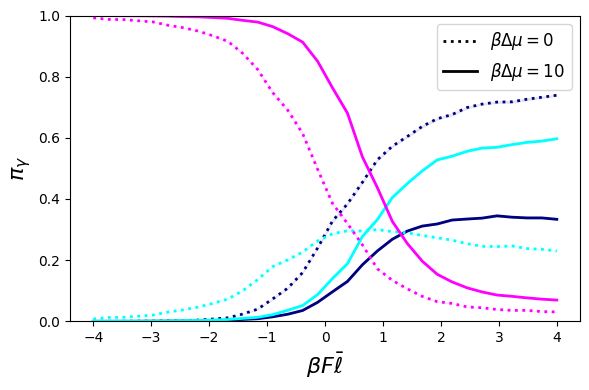

Thinning stats:
  n_proposals: 310
  n_accept: 170
  n_reject: 140
  accept_rate: 0.5483870967741935
  reject_rate: 0.45161290322580644
  bound_mode: adaptive
  safety: 2.0
  global_bound: 5.483365653307591
  bound_violations: 64
  bound_viol_rate: 0.2064516129032258


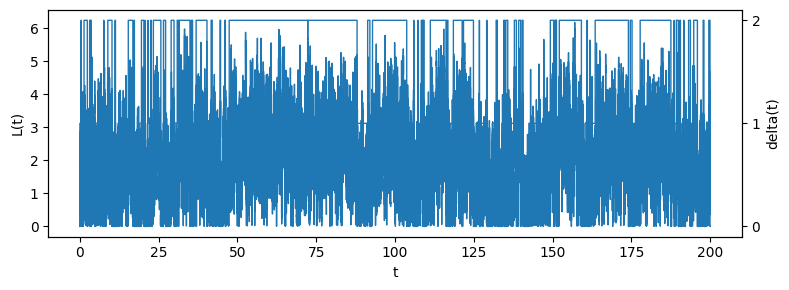

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.lines import Line2D

# =============================================================================
# DEFAULT (NON-DIMENSIONALISED) PARAMETERS
# =============================================================================
k = 1.0                      # k* = beta * k_phys * ellbar^2
delta_mu = 10.0              # beta * Delta mu_phys
F = 1.0                      # beta * F_phys * ellbar
mobility_p = 10.0            # mu* = (mu_p_phys * k_m) / (beta * ellbar^2)
Discrete_internal_states = np.array([1.0, 2.0, 3.0])  # ell/ellbar for states
# time is in units t* = k_m t, so effectively k_m = 1 in these equations

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def epsilon(gamma, delta, n=3):
    """+1 for clockwise (delta -> delta+1), -1 for anticlockwise (delta -> delta-1), 0 otherwise."""
    if gamma == (delta + 1) % n:
        return +1
    if gamma == (delta - 1) % n:
        return -1
    return 0


def Delta_U(L, gamma, delta, k, States, Uell=None):
    """
    Dimensionless energy difference:
      ΔU_{γδ}(L) = (k/2)[(L-ℓ_γ)^2 - (L-ℓ_δ)^2] + U_ell(γ)-U_ell(δ)
    We are working with beta absorbed, so U is dimensionless and k is already k*.
    """
    n = len(States)
    if Uell is None:
        Uell = np.zeros(n)
    return 0.5 * k * ((L - States[gamma])**2 - (L - States[delta])**2) + (Uell[gamma] - Uell[delta])


def wca_force(L, eps_rep=1.0, sigma=1.0):
    """
    Weeks–Chandler–Andersen repulsive LJ force along L:
      F_rep(L) = - dU/dL
    with cutoff rc = 2^(1/6) sigma.
    eps_rep is dimensionless if beta is absorbed.
    """
    rc = (2.0 ** (1.0 / 6.0)) * sigma
    if L <= 0.0:
        return 1e12
    if L >= rc:
        return 0.0

    inv = sigma / L
    inv6 = inv**6
    inv12 = inv6**2
    return 24.0 * eps_rep * (2.0 * inv12 - inv6) / L


def rate_matrix_M(L, delmu, k, States, Uell=None, drive_den=None):
    """
    Generator M with convention:
      M[gamma, delta] = rate(delta -> gamma)
    Columns sum to 0.
    """
    n = len(States)
    if drive_den is None:
        drive_den = 2.0 * n  # for n=3 -> 6

    M = np.zeros((n, n), dtype=float)
    for delta in range(n):
        for gamma in ((delta + 1) % n, (delta - 1) % n):
            eps = epsilon(gamma, delta, n)
            dU = Delta_U(L, gamma, delta, k, States=States, Uell=Uell)
            # k_m = 1 in nondim time
            M[gamma, delta] = np.exp(delmu * eps / drive_den) / (1.0 + np.exp(dU))

    M[np.arange(n), np.arange(n)] = -np.sum(M, axis=0)
    return M


def master_eqn_step(p, L, delmu, k, States, dt, Uell=None, drive_den=None, renormalise=False):
    """Explicit Euler for dp/dt = M(L) p (mostly for debugging / comparisons)."""
    M = rate_matrix_M(L, delmu, k, States, Uell=Uell, drive_den=drive_den)
    p_next = p + dt * (M @ p)

    return p_next


# =============================================================================
# GILLESPIE / THINNING HELPERS
# =============================================================================
def outgoing_moves_and_rates(L, delta, delmu, k, States, Uell=None, drive_den=None):
    """Two outgoing neighbour transitions only."""
    n = len(States)
    if drive_den is None:
        drive_den = 2.0 * n

    moves = []
    for gamma in ((delta + 1) % n, (delta - 1) % n):
        eps = epsilon(gamma, delta, n)
        dU = Delta_U(L, gamma, delta, k, States=States, Uell=Uell)
        r = np.exp(delmu * eps / drive_den) / (1.0 + np.exp(dU))  # k_m=1
        moves.append((gamma, r))
    return moves


def lambda_global_upperbound(delta_mu, drive_den):
    """
    Safe GLOBAL upper bound:
    logistic factor <= 1, so each outgoing <= exp(±delta_mu/drive_den)
    sum <= 2 cosh(delta_mu/drive_den)
    """
    return 2.0 * np.cosh(delta_mu / drive_den)


# =============================================================================
# LANGEVIN INTEGRATOR
# =============================================================================
def evolve_L_for_time(
    L0, delta, w, dt_mech, F, k, States, mobility_p, rng,
    *,
    use_wca=True,
    eps_rep=1.0, sigma=1.0,
    hard_wall="reflect",          # "reflect" | "clamp" | "reject"
    upper_wall=None,              # None or float (hard wall at L=upper_wall)
    record=False,
    t0=0.0
):
    """
    Euler–Maruyama with hard wall(s).

    dL = 2*mu*[ -F - k(L-ell_delta) + Frep(L) ] dt + sqrt(4*mu) dW

    hard_wall at L=0 handled by:
      - reflect: L <- -L if proposed negative
      - clamp:   L <- 0
      - reject:  stay at old L

    upper_wall (optional) handled by reflecting/clamping similarly.
    """
    if w <= 0.0:
        if record:
            return float(L0), np.array([t0]), np.array([float(L0)])
        return float(L0)

    n_steps = int(np.ceil(w / dt_mech))
    dt = w / n_steps
    ell_state = States[delta]
    L = float(L0)

    if record:
        t_arr = np.empty(n_steps + 1, dtype=float)
        L_arr = np.empty(n_steps + 1, dtype=float)
        t_arr[0] = t0
        L_arr[0] = L

    sqrt4mu = np.sqrt(4.0 * mobility_p)

    for i in range(n_steps):
        Frep = wca_force(L, eps_rep=eps_rep, sigma=sigma) if use_wca else 0.0
        drift = 2.0 * mobility_p * (-F - k * (L - ell_state) + Frep)
        L_prop = L + drift * dt + sqrt4mu * np.sqrt(dt) * rng.normal()

        # lower wall at 0
        if L_prop < 0.0:
            if hard_wall == "reflect":
                L_prop = -L_prop
            elif hard_wall == "clamp":
                L_prop = 0.0
            elif hard_wall == "reject":
                L_prop = L
            else:
                raise ValueError("hard_wall must be 'reflect', 'clamp', or 'reject'")

        # optional upper wall
        if upper_wall is not None and L_prop > upper_wall:
            if hard_wall == "reflect":
                L_prop = 2.0 * upper_wall - L_prop
                # if it reflected past 0 (rare), apply lower wall again
                if L_prop < 0.0:
                    L_prop = -L_prop
            elif hard_wall == "clamp":
                L_prop = upper_wall
            elif hard_wall == "reject":
                L_prop = L

        L = L_prop

        if record:
            t_arr[i + 1] = t0 + (i + 1) * dt
            L_arr[i + 1] = L

    if record:
        return L, t_arr, L_arr
    return L


# =============================================================================
# MAIN: SINGLE DIMER THINNING SIMULATION
# =============================================================================
def simulate_single_dimer_thinning(
    T,
    L0=2.0,
    delta0=0,
    *,
    delta_mu=delta_mu, k=k, States=Discrete_internal_states, Uell=None,
    mobility_p=mobility_p, F=F,
    dt_mech=1e-3,
    drive_den=None,
    burn_in=0.0,
    seed=None,
    # recording
    record_events=False,           # accepted jumps only
    record_trajectory=False,       # values at proposal times
    record_Langevin_path=False,    # all EM substeps (can get large!)
    # boundaries / forces
    hard_wall="reflect",
    upper_wall=None,
    use_wca=True,
    eps_rep=1.0,
    sigma=1.0,
    # thinning bound control
    bound_mode="adaptive",         # "global" | "adaptive"
    safety=2.0,                    # for adaptive: lambda_bar = safety * lam0
    min_lambda_bar=1e-12
):
    """
    Thinning simulation for one dimer.

    bound_mode:
      - "global": uses safe global bound 2 cosh(delta_mu/drive_den)
      - "adaptive": uses lambda_bar = safety * lam0 (lam0 at start of interval)
                    This is tighter, but not guaranteed unless safety is large.
                    We track violations where lam_end > lambda_bar.
    """
    rng = np.random.default_rng(seed)
    n = len(States)

    if drive_den is None:
        drive_den = 2.0 * n  # for n=3 -> 6

    # safe global bound (always)
    lambda_global = lambda_global_upperbound(delta_mu, drive_den)

    t = 0.0
    L = float(L0)
    delta = int(delta0)

    # time-weighted occupancy
    time_in_state = np.zeros(n, dtype=float)

    # accepted-jump records
    times_acc, Ls_acc, states_acc = [], [], []

    # proposal-time trajectory records
    t_traj, L_traj, d_traj = [], [], []

    # full EM path (can be huge)
    t_path, L_path, d_path = [], [], []

    # thinning stats
    n_proposals = 0
    n_accept = 0
    n_reject = 0
    n_bound_viol = 0

    if record_trajectory:
        t_traj.append(t)
        L_traj.append(L)
        d_traj.append(delta)

    while t < T:
        # --- choose lambda_bar ---
        if bound_mode == "global":
            lambda_bar = max(min_lambda_bar, lambda_global)
        elif bound_mode == "adaptive":
            moves0 = outgoing_moves_and_rates(L, delta, delta_mu, k, States, Uell=Uell, drive_den=drive_den)
            lam0 = moves0[0][1] + moves0[1][1]
            lambda_bar = max(min_lambda_bar, safety * lam0)
        else:
            raise ValueError("bound_mode must be 'global' or 'adaptive'")

        # propose waiting time
        w = -np.log(rng.random()) / lambda_bar
        t_new = t + w

        # time-in-state accumulation (after burn-in)
        seg_start = max(t, burn_in)
        seg_end = min(t_new, T)
        if seg_end > seg_start:
            time_in_state[delta] += (seg_end - seg_start)

        # evolve L on [t, t_new)
        if record_Langevin_path:
            L, tt, LL = evolve_L_for_time(
                L0=L, delta=delta, w=w, dt_mech=dt_mech,
                F=F, k=k, States=States, mobility_p=mobility_p, rng=rng,
                use_wca=use_wca, eps_rep=eps_rep, sigma=sigma,
                hard_wall=hard_wall, upper_wall=upper_wall,
                record=True, t0=t
            )
            t_path.extend(tt.tolist())
            L_path.extend(LL.tolist())
            d_path.extend([delta] * len(tt))
        else:
            L = evolve_L_for_time(
                L0=L, delta=delta, w=w, dt_mech=dt_mech,
                F=F, k=k, States=States, mobility_p=mobility_p, rng=rng,
                use_wca=use_wca, eps_rep=eps_rep, sigma=sigma,
                hard_wall=hard_wall, upper_wall=upper_wall,
                record=False
            )

        t = t_new
        if t >= T:
            break

        if record_trajectory:
            t_traj.append(t)
            L_traj.append(L)
            d_traj.append(delta)

        # compute true rate at end
        moves = outgoing_moves_and_rates(L, delta, delta_mu, k, States, Uell=Uell, drive_den=drive_den)
        lam = moves[0][1] + moves[1][1]

        n_proposals += 1

        # if adaptive bound was too small, track it
        if lam > lambda_bar:
            n_bound_viol += 1

        # accept with prob min(1, lam/lambda_bar)
        acc_prob = 0.0 if lam <= 0.0 else min(1.0, lam / lambda_bar)

        if rng.random() >= acc_prob:
            n_reject += 1
            continue

        n_accept += 1

        # choose which move
        x = rng.random() * lam
        if x <= moves[0][1]:
            delta = moves[0][0]
        else:
            delta = moves[1][0]

        if record_events and t >= burn_in:
            times_acc.append(t)
            Ls_acc.append(L)
            states_acc.append(delta)

    # pi_gamma
    total = time_in_state.sum()
    pi = time_in_state / total if total > 0 else np.ones(n) / n

    stats = {
        "n_proposals": n_proposals,
        "n_accept": n_accept,
        "n_reject": n_reject,
        "accept_rate": (n_accept / n_proposals) if n_proposals > 0 else np.nan,
        "reject_rate": (n_reject / n_proposals) if n_proposals > 0 else np.nan,
        "bound_mode": bound_mode,
        "safety": safety if bound_mode == "adaptive" else None,
        "global_bound": lambda_global,
        "bound_violations": n_bound_viol,
        "bound_viol_rate": (n_bound_viol / n_proposals) if n_proposals > 0 else np.nan,
    }

    out = {"pi": pi, "stats": stats}

    if record_events:
        out["accepted_events"] = (np.array(times_acc), np.array(Ls_acc), np.array(states_acc))
    if record_trajectory:
        out["proposal_traj"] = (np.array(t_traj), np.array(L_traj), np.array(d_traj))
    if record_Langevin_path:
        out["langevin_path"] = (np.array(t_path), np.array(L_path), np.array(d_path))

    return out


# =============================================================================
# PI CURVE (FIGURE-2 STYLE)
# =============================================================================
def pi_curve_vs_betaFell(
    betaFell_vals, *,
    delta_mu_val, T, burn_in,
    L0=2.0, delta0=0, seed0=0,
    drive_den=6.0, dt_mech=1e-3, n_avg=10,
    # dynamics options
    hard_wall="reflect",
    upper_wall=None,
    use_wca=True,
    # thinning bound options
    bound_mode="adaptive",
    safety=2.0
):
    """
    Average pi_gamma over n_avg independent runs for each betaFell.
    Returns mean and standard error.
    """
    n_states = len(Discrete_internal_states)
    pi_mean = np.zeros((len(betaFell_vals), n_states))
    pi_se = np.zeros((len(betaFell_vals), n_states))

    for i, betaFell in enumerate(tqdm(betaFell_vals, desc=f"delta_mu={delta_mu_val}")):
        F_here = float(betaFell)  # since ellbar=1, beta=1

        samples = np.zeros((n_avg, n_states))
        for r in range(n_avg):
            res = simulate_single_dimer_thinning(
                T=T, L0=L0, delta0=delta0,
                delta_mu=delta_mu_val, k=k, States=Discrete_internal_states, Uell=None,
                mobility_p=mobility_p, F=F_here,
                dt_mech=dt_mech,
                drive_den=drive_den,
                burn_in=burn_in,
                seed=seed0 + 100000*i + r,
                record_events=False,
                record_trajectory=False,
                record_Langevin_path=False,
                hard_wall=hard_wall,
                upper_wall=upper_wall,
                use_wca=use_wca,
                bound_mode=bound_mode,
                safety=safety
            )
            samples[r] = res["pi"]

        pi_mean[i] = samples.mean(axis=0)
        pi_se[i] = samples.std(axis=0, ddof=1) / np.sqrt(n_avg)

    return pi_mean, pi_se


# =============================================================================
# PLOTTING: SINGLE TRAJECTORY
# =============================================================================
def plot_single_trajectory(res, which="langevin_path"):
    """
    which = "langevin_path" (full EM path) or "proposal_traj" (proposal sampling).
    """
    if which not in res:
        raise ValueError(f"'{which}' not in result. Run with record_Langevin_path=True or record_trajectory=True.")

    t, L, d = res[which]

    fig, ax1 = plt.subplots(figsize=(8, 3))
    ax1.plot(t, L, linewidth=1)
    ax1.set_xlabel("t")
    ax1.set_ylabel("L(t)")

    ax2 = ax1.twinx()
    ax2.step(t, d, where="post", linewidth=1)
    ax2.set_ylabel("delta(t)")
    ax2.set_yticks([0, 1, 2])

    plt.tight_layout()
    plt.show()


# =============================================================================
# RUN EXAMPLE
# =============================================================================
if __name__ == "__main__":
    # ---------------- figure-2 style pi_gamma vs betaFell ----------------
    betaFell = np.linspace(-4, 4, 32)

    T = 1000.0
    burn = 500.0

    # If you use WCA, dt_mech usually needs to be SMALL.
    dt_mech_plot = 1e-3

    # equilibrium
    pi_eq, se_eq = pi_curve_vs_betaFell(
        betaFell,
        delta_mu_val=0.0,
        T=T, burn_in=burn,
        drive_den=6.0, dt_mech=dt_mech_plot, n_avg=40,
        hard_wall="reflect",
        upper_wall=None,      # set e.g. 6.0 if you want a top wall too
        use_wca=False,
        bound_mode="adaptive",
        safety=2.0
    )

    # driven
    pi_dr, se_dr = pi_curve_vs_betaFell(
        betaFell,
        delta_mu_val=delta_mu,
        T=T, burn_in=burn,
        drive_den=6.0, dt_mech=dt_mech_plot, n_avg=40,
        hard_wall="reflect",
        upper_wall=None,
        use_wca=False,
        bound_mode="adaptive",
        safety=2.0
    )

    labels_gamma = [r"$\ell=\bar{\ell}$", r"$\ell=2\bar{\ell}$", r"$\ell=3\bar{\ell}$"]
    colors = ["navy", "cyan", "magenta"]

    plt.figure(figsize=(6, 4))
    for g in range(3):
        plt.plot(betaFell, pi_eq[:, g], linestyle=":", linewidth=2, color=colors[g])
        plt.plot(betaFell, pi_dr[:, g], linestyle="-", linewidth=2, color=colors[g])

        plt.fill_between(betaFell, pi_dr[:, g] - se_dr[:, g], pi_dr[:, g] + se_dr[:, g],
                         color=colors[g], alpha=0.15, linewidth=0)
        plt.fill_between(betaFell, pi_eq[:, g] - se_eq[:, g], pi_eq[:, g] + se_eq[:, g],
                         color=colors[g], alpha=0.10, linewidth=0)

    plt.xlabel(r"$\beta F \bar{\ell}$", fontsize=16)
    plt.ylabel(r"$\pi_\gamma$", fontsize=16)
    plt.ylim(0, 1)

    legend_lines = [
        Line2D([0], [0], color="black", linestyle=":", linewidth=2, label=r"$\beta\Delta\mu=0$"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2, label=r"$\beta\Delta\mu=10$")
    ]
    plt.legend(handles=legend_lines, fontsize=12, loc="best")
    plt.tight_layout()
    plt.show()

    # ---------------- one long trajectory + stats ----------------
    res = simulate_single_dimer_thinning(
        T=200.0,
        L0=2.0,
        delta0=0,
        delta_mu=delta_mu,
        F=0.5,
        dt_mech=1e-3,
        burn_in=0.0,
        seed=0,
        drive_den=6.0,
        record_trajectory=True,
        record_Langevin_path=True,
        hard_wall="reflect",
        upper_wall=None,     # try e.g. upper_wall=6.0 if you want a top wall too
        use_wca=False,
        bound_mode="adaptive",
        safety=2.0
    )

    print("Thinning stats:")
    for k_, v_ in res["stats"].items():
        print(f"  {k_}: {v_}")

    plot_single_trajectory(res, which="langevin_path")
    # plot_single_trajectory(res, which="proposal_traj")



Not quite sure why: 
1. it's noisy even after averaging on 25 runs ~ 20 ish mins still noisy though?
2. its slow? 
3. ~~looks wrong~~ , It was the wca repulsion term!

below is a better thinning algorithm however it tends to still be noisy and takes longer to run

sweep R (pinned Gillespie): 100%|██████████| 30/30 [05:36<00:00, 11.20s/it]


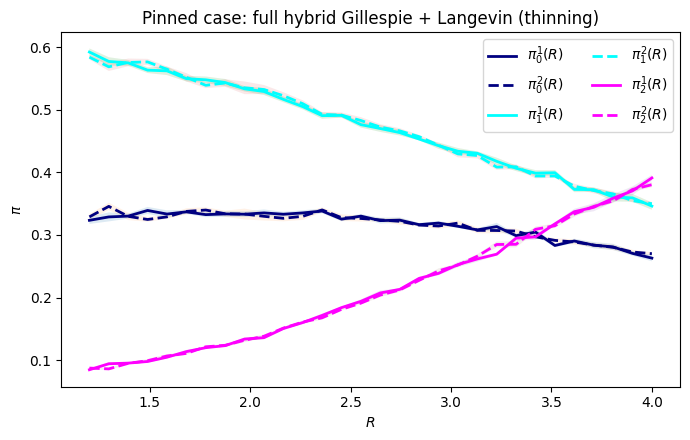

In [79]:


# =============================================================================
### helper functions are above!!!
# =============================================================================
# =============================================================================
# Mechanics: pinned middle bead x = L1 in [0,R], L2 = R-x
# =============================================================================
def reflect_0R(x, R):
    # robust reflection (handles overshoot)
    if x < 0.0:
        x = -x
    if x > R:
        x = 2.0 * R - x
    # if dt huge, could still be out; do a second pass
    if x < 0.0:
        x = -x
    if x > R:
        x = 2.0 * R - x
    # safety clamp
    return min(max(x, 0.0), R)

def evolve_x_for_time_pinned(
    x0, g1, g2, w, dt_mech, *,
    beta=1.0, mobility_p=10.0, k=1.0, R=3.0,
    States1=None, States2=None,
    rng=None,
    record=False, t0=0.0
):
    """
    Euler–Maruyama for:
      dx = -2 mu_p k (x - mu(g1,g2)) dt + sqrt(2 mu_p / beta) dW
    with reflecting walls at 0 and R.
    """
    if rng is None:
        rng = np.random.default_rng()

    if w <= 0.0:
        if record:
            return float(x0), np.array([t0]), np.array([float(x0)])
        return float(x0)

    n_steps = int(np.ceil(w / dt_mech))
    dt = w / n_steps

    x = float(x0)

    if record:
        tt = np.empty(n_steps + 1, dtype=float)
        xx = np.empty(n_steps + 1, dtype=float)
        tt[0] = t0
        xx[0] = x

    for i in range(n_steps):
        ell1 = States1[g1]
        ell2 = States2[g2]
        mu = 0.5 * (R + ell1 - ell2)

        drift = -2.0 * mobility_p * k * (x - mu)
        x = x + drift * dt + np.sqrt(2.0 * mobility_p / beta) * np.sqrt(dt) * rng.normal()
        x = reflect_0R(x, R)

        if record:
            tt[i + 1] = t0 + (i + 1) * dt
            xx[i + 1] = x

    if record:
        return x, tt, xx
    return x

# =============================================================================
# Full hybrid thinning Gillespie: 2 springs pinned
# =============================================================================
def simulate_two_springs_pinned_thinning(
    T,
    *,
    beta=1.0,
    k=1.0,
    mobility_p=10.0,
    R=3.0,
    States1=np.array([1.0, 2.0, 3.0]),
    States2=np.array([1.0, 2.0, 3.0]),
    delta_mu1=10.0,
    delta_mu2=10.0,
    g10=0,
    g20=0,
    x0=1.0,            # x=L1 in [0,R]
    dt_mech=1e-3,
    burn_in=0.0,
    seed=None,
    drive_den=None,
    bound_mode="global",   # "global" is safe
    safety=2.0,            # for adaptive
    record_events=False,
    record_traj=False,
    record_path=False,     # store full EM path per interval (can be big)
):
    rng = np.random.default_rng(seed)
    n = len(States1)
    if drive_den is None:
        drive_den = 2.0 * n  # 6 for n=3

    # Safe global upper bound for total hazard (spring1 + spring2)
    lam_bar_global = lambda_global_upperbound(delta_mu1, drive_den) + lambda_global_upperbound(delta_mu2, drive_den)

    t = 0.0
    x = float(x0)
    g1, g2 = int(g10), int(g20)

    # time-weighted occupancy
    time_joint = np.zeros((n, n), dtype=float)

    # records
    events = []
    traj = []   # proposal times (t, x, g1, g2)
    path = []   # (t, x, g1, g2) full EM points if record_path

    n_prop = n_acc = n_rej = 0

    while t < T:
        # choose bound
        if bound_mode == "global":
            lam_bar = lam_bar_global
        elif bound_mode == "adaptive":
            L1 = x
            L2 = R - x
            m1 = outgoing_moves_and_rates(L1, g1, delta_mu1, k, States1, drive_den=drive_den)
            m2 = outgoing_moves_and_rates(L2, g2, delta_mu2, k, States2, drive_den=drive_den)
            lam0 = (m1[0][1] + m1[1][1]) + (m2[0][1] + m2[1][1])
            lam_bar = max(1e-12, safety * lam0)
        else:
            raise ValueError("bound_mode must be 'global' or 'adaptive'")

        # propose waiting time
        w = -np.log(rng.random()) / lam_bar
        t_new = t + w

        # accumulate time in current discrete state
        seg_start = max(t, burn_in)
        seg_end = min(t_new, T)
        if seg_end > seg_start:
            time_joint[g1, g2] += (seg_end - seg_start)

        # evolve mechanics over [t,t_new)
        if record_path:
            x, tt, xx = evolve_x_for_time_pinned(
                x, g1, g2, w, dt_mech,
                beta=beta, mobility_p=mobility_p, k=k, R=R,
                States1=States1, States2=States2, rng=rng,
                record=True, t0=t
            )
            for tj, xj in zip(tt, xx):
                path.append((tj, xj, g1, g2))
        else:
            x = evolve_x_for_time_pinned(
                x, g1, g2, w, dt_mech,
                beta=beta, mobility_p=mobility_p, k=k, R=R,
                States1=States1, States2=States2, rng=rng,
                record=False
            )

        t = t_new
        if t >= T:
            break

        if record_traj:
            traj.append((t, x, g1, g2))

        # compute true hazard at event time
        L1 = x
        L2 = R - x
        m1 = outgoing_moves_and_rates(L1, g1, delta_mu1, k, States1, drive_den=drive_den)
        m2 = outgoing_moves_and_rates(L2, g2, delta_mu2, k, States2, drive_den=drive_den)

        channels = [
            ("s1", m1[0][0], m1[0][1]),
            ("s1", m1[1][0], m1[1][1]),
            ("s2", m2[0][0], m2[0][1]),
            ("s2", m2[1][0], m2[1][1]),
        ]
        lam = sum(r for (_, _, r) in channels)

        n_prop += 1
        acc_prob = 0.0 if lam <= 0.0 else min(1.0, lam / lam_bar)

        if rng.random() >= acc_prob:
            n_rej += 1
            continue

        n_acc += 1

        # pick which channel fired
        u = rng.random() * lam
        cum = 0.0
        which, new_state = None, None
        for wch, ns, r in channels:
            cum += r
            if u <= cum:
                which, new_state = wch, int(ns)
                break
        if which is None:
            which, new_state = channels[-1][0], int(channels[-1][1])

        # update discrete state
        if which == "s1":
            g1 = new_state
        else:
            g2 = new_state

        if record_events and t >= burn_in:
            events.append((t, x, g1, g2, which))

    # outputs
    total = time_joint.sum()
    Pi = time_joint / total if total > 0 else np.ones((n, n)) / (n * n)
    pi1 = Pi.sum(axis=1)
    pi2 = Pi.sum(axis=0)

    out = {
        "Pi": Pi,
        "pi1": pi1,
        "pi2": pi2,
        "stats": {
            "n_proposals": n_prop,
            "n_accept": n_acc,
            "n_reject": n_rej,
            "accept_rate": (n_acc / n_prop) if n_prop > 0 else np.nan,
            "bound_mode": bound_mode,
            "global_bound": lam_bar_global,
            "R": R,
        }
    }
    if record_events:
        out["events"] = np.array(events, dtype=object)
    if record_traj:
        out["traj"] = np.array(traj, dtype=float)
    if record_path:
        out["path"] = np.array(path, dtype=float)
    return out

# =============================================================================
# Sweep R and plot pi1(R), pi2(R)
# =============================================================================
def sweep_R_pinned(R_vals, *, T=600.0, burn_in=300.0, n_avg=10, seed0=0, **kwargs):
    States1 = kwargs.get("States1", np.array([1.0, 2.0, 3.0]))
    n = len(States1)

    pi1_mean = np.zeros((len(R_vals), n))
    pi2_mean = np.zeros((len(R_vals), n))
    pi1_se = np.zeros_like(pi1_mean)
    pi2_se = np.zeros_like(pi2_mean)

    for i, R in enumerate(tqdm(R_vals, desc="sweep R (pinned Gillespie)")):
        s1 = np.zeros((n_avg, n))
        s2 = np.zeros((n_avg, n))
        for r in range(n_avg):
            res = simulate_two_springs_pinned_thinning(
                T,
                R=float(R),
                burn_in=burn_in,
                seed=seed0 + 100000*i + r,
                **kwargs
            )
            s1[r] = res["pi1"]
            s2[r] = res["pi2"]

        pi1_mean[i] = s1.mean(axis=0)
        pi2_mean[i] = s2.mean(axis=0)
        pi1_se[i] = s1.std(axis=0, ddof=1) / np.sqrt(n_avg)
        pi2_se[i] = s2.std(axis=0, ddof=1) / np.sqrt(n_avg)

    return pi1_mean, pi2_mean, pi1_se, pi2_se

# =============================================================================
# Example run
# =============================================================================
if __name__ == "__main__":
    beta = 1.0
    k = 1.0
    mobility_p = 100.0

    States1 = np.array([1.0, 2.0, 3.0])
    States2 = np.array([1.0, 2.0, 3.0])  # try States2 = States1 + 0.5 for shift

    delta_mu1 = 10.0
    delta_mu2 = 10.0

    R_vals = np.linspace(1.2, 4.0, 30)

    pi1_m, pi2_m, pi1_se, pi2_se = sweep_R_pinned(
        R_vals,
        T=1000.0,
        burn_in=250.0,
        n_avg=8,
        seed0=0,
        beta=beta,
        k=k,
        mobility_p=mobility_p,
        States1=States1,
        States2=States2,
        delta_mu1=delta_mu1,
        delta_mu2=delta_mu2,
        g10=0,
        g20=0,
        x0=0.5,          # start L1 somewhere inside [0,R]
        dt_mech=1e-3,
        bound_mode="global",  # safe
        record_events=False
    )
    labels_gamma = [r"$\ell=\bar{\ell}$", r"$\ell=2\bar{\ell}$", r"$\ell=3\bar{\ell}$"]
    colors = ["navy", "cyan", "magenta"]
    plt.figure(figsize=(7, 4.5))
    for g in range(len(States1)):
        plt.plot(R_vals, pi1_m[:, g], lw=2, label=fr"$\pi_{{{g}}}^{(1)}(R)$",color=colors[g])
        plt.plot(R_vals, pi2_m[:, g], lw=2, ls="--", label=fr"$\pi_{{{g}}}^{(2)}(R)$",color=colors[g])
        plt.fill_between(R_vals, pi1_m[:, g]-pi1_se[:, g], pi1_m[:, g]+pi1_se[:, g], alpha=0.15)
        plt.fill_between(R_vals, pi2_m[:, g]-pi2_se[:, g], pi2_m[:, g]+pi2_se[:, g], alpha=0.10)

    plt.xlabel(r"$R$")
    plt.ylabel(r"$\pi$")
    plt.title("Pinned case: full hybrid Gillespie + Langevin (thinning)")
    plt.legend(ncol=2, fontsize=10)
    plt.tight_layout()
    plt.show()


sweep R: 100%|██████████| 30/30 [29:03<00:00, 58.11s/it]   


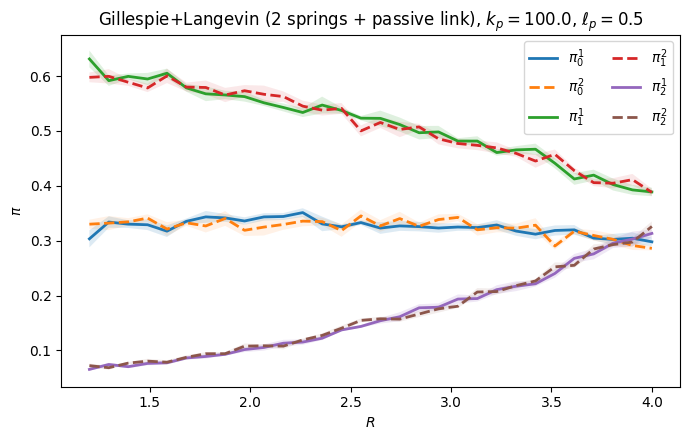

In [ ]:


# =============================================================================
# MECHANICS: coupled (L1,L2) Langevin step with passive spring
# =============================================================================
def reflect_simplex(L1, L2, R, max_iter=6):
    """
    Reflect into simplex: L1>=0, L2>=0, L1+L2<=R.
    """
    for _ in range(max_iter):
        # reflect at L1=0
        if L1 < 0.0:
            L1 = -L1
        # reflect at L2=0
        if L2 < 0.0:
            L2 = -L2
        # reflect at L1+L2=R
        s = L1 + L2 - R
        if s > 0.0:
            # reflect point across line L1+L2=R: subtract s along (1,1)
            L1 = L1 - s
            L2 = L2 - s
            continue
        break

    # final safety clamps (should rarely trigger)
    L1 = max(L1, 0.0)
    L2 = max(L2, 0.0)
    s = L1 + L2 - R
    if s > 0.0:
        L1 -= 0.5 * s
        L2 -= 0.5 * s
        L1 = max(L1, 0.0)
        L2 = max(L2, 0.0)
    return L1, L2

def forces_L1L2(L1, L2, g1, g2, *,
                beta, k, kp, R, ell_p,
                States1, States2,
                use_wca=False, eps_rep=1.0, sigma=1.0):
    """
    Conservative forces f = -∇_L U, where:
      U = k/2[(L1-ell1)^2 + (L2-ell2)^2] + kp/2*(R-L1-L2-ell_p)^2 + Urep(L1)+Urep(L2)+Urep(Lp)
    Lp = R - L1 - L2
    """
    ell1 = States1[g1]
    ell2 = States2[g2]
    tildeR = R - ell_p
    S = L1 + L2

    # harmonic + passive
    f1 = -k * (L1 - ell1) - kp * (S - tildeR)
    f2 = -k * (L2 - ell2) - kp * (S - tildeR)

    if use_wca:
        Lp = R - L1 - L2
        # WCA on L1 and L2 pushes them away from 0
        f1 += wca_force(L1, eps_rep=eps_rep, sigma=sigma)
        f2 += wca_force(L2, eps_rep=eps_rep, sigma=sigma)
        # WCA on Lp: since Lp decreases when L1/L2 increase,
        # its force tends to reduce L1/L2 when Lp is small.
        fLp = wca_force(Lp, eps_rep=eps_rep, sigma=sigma)
        f1 -= fLp
        f2 -= fLp

    return np.array([f1, f2], dtype=float)

def evolve_L1L2_for_time(L10, L20, g1, g2, w, dt_mech, *,
                         beta=1.0, mobility_p=10.0,
                         k=1.0, kp=1.0, R=3.0, ell_p=0.0,
                         States1=None, States2=None,
                         use_wca=False, eps_rep=1.0, sigma=1.0,
                         enforce_simplex=True,
                         rng=None,
                         record=False, t0=0.0):
    """
    Euler–Maruyama for coupled 2D Langevin:
      dL = drift dt + sqrt(2 beta^{-1} M) dW
    with mobility matrix M = mobility_p * [[2,-1],[-1,2]] (nearest-neighbour correlated).

    Optionally reflect into simplex L1>=0, L2>=0, L1+L2<=R after each substep.
    """
    if rng is None:
        rng = np.random.default_rng()

    if w <= 0.0:
        if record:
            return float(L10), float(L20), np.array([t0]), np.array([float(L10)]), np.array([float(L20)])
        return float(L10), float(L20)

    n_steps = int(np.ceil(w / dt_mech))
    dt = w / n_steps

    # mobility matrix
    B = np.array([[2.0, -1.0],
                  [-1.0, 2.0]], dtype=float)
    M = mobility_p * B

    # noise prefactor: chol(2 beta^{-1} M)
    Sigma = np.linalg.cholesky((2.0 / beta) * M)

    L1 = float(L10)
    L2 = float(L20)

    if record:
        tt = np.empty(n_steps + 1, dtype=float)
        L1s = np.empty(n_steps + 1, dtype=float)
        L2s = np.empty(n_steps + 1, dtype=float)
        tt[0] = t0
        L1s[0] = L1
        L2s[0] = L2

    for i in range(n_steps):
        f = forces_L1L2(L1, L2, g1, g2,
                        beta=beta, k=k, kp=kp, R=R, ell_p=ell_p,
                        States1=States1, States2=States2,
                        use_wca=use_wca, eps_rep=eps_rep, sigma=sigma)
        drift = M @ f

        dW = rng.normal(size=2)
        dL = drift * dt + (Sigma @ dW) * np.sqrt(dt)
        L1 += dL[0]
        L2 += dL[1]

        if enforce_simplex:
            L1, L2 = reflect_simplex(L1, L2, R)

        if record:
            tt[i + 1] = t0 + (i + 1) * dt
            L1s[i + 1] = L1
            L2s[i + 1] = L2

    if record:
        return L1, L2, tt, L1s, L2s
    return L1, L2

# =============================================================================
# GILLESPIE (THINNING) for 2 springs: 9-state (g1,g2) + continuous (L1,L2)
# =============================================================================
def simulate_two_springs_thinning(
    T,
    *,
    beta=1.0,
    k=1.0,
    kp=5.0,
    R=3.0,
    ell_p=0.0,
    mobility_p=10.0,
    States1=np.array([1.0, 2.0, 3.0]),
    States2=np.array([1.0, 2.0, 3.0]),
    delta_mu1=10.0,
    delta_mu2=10.0,
    g10=0,
    g20=0,
    L10=1.0,
    L20=1.0,
    dt_mech=1e-3,
    burn_in=0.0,
    seed=None,
    drive_den=None,
    # mechanics options
    enforce_simplex=True,
    use_wca=False,
    eps_rep=1.0,
    sigma=1.0,
    # thinning
    bound_mode="global",   # "global" recommended for correctness
    safety=2.0,            # for adaptive only
    # recording
    record_events=False,
    record_path=False
):
    """
    Full hybrid simulation:
      - mechanics: coupled Langevin in (L1,L2) under U(L1,L2;g1,g2)
      - chemistry: two independent 3-cycle internal states with rates depending on their own Li

    Event channels (4 total):
      g1 -> g1±1   with rates depending on L1
      g2 -> g2±1   with rates depending on L2
    """
    rng = np.random.default_rng(seed)
    n1 = len(States1)
    n2 = len(States2)
    if drive_den is None:
        drive_den = 2.0 * 3  # for 3-state ring: 6

    # safe global upper bound for total hazard:
    lam_bar_global = lambda_global_upperbound(delta_mu1, drive_den) + lambda_global_upperbound(delta_mu2, drive_den)

    t = 0.0
    L1, L2 = float(L10), float(L20)
    g1, g2 = int(g10), int(g20)

    # time-weighted occupancy after burn-in
    time_joint = np.zeros((n1, n2), dtype=float)

    # event records
    events = []  # (t, L1, L2, g1, g2, which_spring, new_state)

    # optional path record at proposal times
    path = []  # (t, L1, L2, g1, g2)

    n_prop = n_acc = n_rej = 0

    while t < T:
        if bound_mode == "global":
            lam_bar = lam_bar_global
        elif bound_mode == "adaptive":
            m1 = outgoing_moves_and_rates(L1, g1, delta_mu1, k, States1, drive_den=drive_den)
            m2 = outgoing_moves_and_rates(L2, g2, delta_mu2, k, States2, drive_den=drive_den)
            lam0 = (m1[0][1] + m1[1][1]) + (m2[0][1] + m2[1][1])
            lam_bar = max(1e-12, safety * lam0)
        else:
            raise ValueError("bound_mode must be 'global' or 'adaptive'")

        # propose waiting time
        w = -np.log(rng.random()) / lam_bar
        t_new = t + w

        # accumulate occupancy time (after burn-in)
        seg_start = max(t, burn_in)
        seg_end = min(t_new, T)
        if seg_end > seg_start:
            time_joint[g1, g2] += (seg_end - seg_start)

        # evolve mechanics for duration w with fixed (g1,g2)
        if record_path:
            L1, L2, tt, L1s, L2s = evolve_L1L2_for_time(
                L1, L2, g1, g2, w, dt_mech,
                beta=beta, mobility_p=mobility_p,
                k=k, kp=kp, R=R, ell_p=ell_p,
                States1=States1, States2=States2,
                use_wca=use_wca, eps_rep=eps_rep, sigma=sigma,
                enforce_simplex=enforce_simplex,
                rng=rng,
                record=True, t0=t
            )
            # store only end-of-interval in "path" (keeps it smaller)
        else:
            L1, L2 = evolve_L1L2_for_time(
                L1, L2, g1, g2, w, dt_mech,
                beta=beta, mobility_p=mobility_p,
                k=k, kp=kp, R=R, ell_p=ell_p,
                States1=States1, States2=States2,
                use_wca=use_wca, eps_rep=eps_rep, sigma=sigma,
                enforce_simplex=enforce_simplex,
                rng=rng,
                record=False
            )

        t = t_new
        if t >= T:
            break

        if record_path:
            path.append((t, L1, L2, g1, g2))

        # true hazard at event time
        m1 = outgoing_moves_and_rates(L1, g1, delta_mu1, k, States1, drive_den=drive_den)
        m2 = outgoing_moves_and_rates(L2, g2, delta_mu2, k, States2, drive_den=drive_den)

        rates = [
            ("s1", m1[0][0], m1[0][1]),
            ("s1", m1[1][0], m1[1][1]),
            ("s2", m2[0][0], m2[0][1]),
            ("s2", m2[1][0], m2[1][1]),
        ]
        lam = sum(r for (_, _, r) in rates)

        n_prop += 1

        # accept/reject
        acc_prob = 0.0 if lam <= 0.0 else min(1.0, lam / lam_bar)
        if rng.random() >= acc_prob:
            n_rej += 1
            continue
        n_acc += 1

        # choose channel
        x = rng.random() * lam
        cum = 0.0
        chosen = None
        for which, new_state, r in rates:
            cum += r
            if x <= cum:
                chosen = (which, new_state)
                break
        if chosen is None:
            # numerical fallback
            chosen = (rates[-1][0], rates[-1][1])

        which, new_state = chosen
        if which == "s1":
            g1 = int(new_state)
        else:
            g2 = int(new_state)

        if record_events and t >= burn_in:
            events.append((t, L1, L2, g1, g2, which, new_state))

    total = time_joint.sum()
    Pi = time_joint / total if total > 0 else np.ones((n1, n2)) / (n1 * n2)
    pi1 = Pi.sum(axis=1)
    pi2 = Pi.sum(axis=0)

    out = {
        "Pi": Pi,
        "pi1": pi1,
        "pi2": pi2,
        "stats": {
            "n_proposals": n_prop,
            "n_accept": n_acc,
            "n_reject": n_rej,
            "accept_rate": (n_acc / n_prop) if n_prop > 0 else np.nan,
            "bound_mode": bound_mode,
            "global_bound": lam_bar_global,
            "R": R,
            "kp": kp,
            "ell_p": ell_p,
        },
    }
    if record_events:
        out["events"] = events
    if record_path:
        out["path"] = np.array(path, dtype=float)
    return out

# =============================================================================
# Sweep R and plot pi1(R), pi2(R)
# =============================================================================
def sweep_R_pi(
    R_vals,
    *,
    T=500.0,
    burn_in=250.0,
    n_avg=10,
    seed0=0,
    **kwargs
):
    """
    Average pi1, pi2 over n_avg independent runs for each R.
    """
    States1 = kwargs.get("States1", np.array([1.0, 2.0, 3.0]))
    n = len(States1)
    pi1_mean = np.zeros((len(R_vals), n))
    pi2_mean = np.zeros((len(R_vals), n))
    pi1_se = np.zeros_like(pi1_mean)
    pi2_se = np.zeros_like(pi2_mean)

    for i, R in enumerate(tqdm(R_vals, desc="sweep R")):
        samples1 = np.zeros((n_avg, n))
        samples2 = np.zeros((n_avg, n))
        for r in range(n_avg):
            res = simulate_two_springs_thinning(
                T,
                R=float(R),
                burn_in=burn_in,
                seed=seed0 + 100000*i + r,
                **kwargs
            )
            samples1[r] = res["pi1"]
            samples2[r] = res["pi2"]

        pi1_mean[i] = samples1.mean(axis=0)
        pi2_mean[i] = samples2.mean(axis=0)
        pi1_se[i] = samples1.std(axis=0, ddof=1) / np.sqrt(n_avg)
        pi2_se[i] = samples2.std(axis=0, ddof=1) / np.sqrt(n_avg)

    return pi1_mean, pi2_mean, pi1_se, pi2_se

if __name__ == "__main__":
    # Example parameters (match your style)
    beta = 1.0
    k = 1.0
    mobility_p = 10.0
    States1 = np.array([1.0, 2.0, 3.0])
    States2 = np.array([1.0, 2.0, 3.0])

    delta_mu1 = 10.0
    delta_mu2 = 10.0

    # Passive spring
    kp = 100.0
    ell_p = 0.5

    # Initial conditions
    g10, g20 = 0, 0
    L10, L20 = 1.0, 1.0

    # Sweep R
    R_vals = np.linspace(1.2, 4.0, 30)

    pi1_m, pi2_m, pi1_se, pi2_se = sweep_R_pi(
        R_vals,
        T=400.0,
        burn_in=200.0,
        n_avg=8,
        seed0=0,
        beta=beta,
        k=k,
        kp=kp,
        ell_p=ell_p,
        mobility_p=mobility_p,
        States1=States1,
        States2=States2,
        delta_mu1=delta_mu1,
        delta_mu2=delta_mu2,
        g10=g10,
        g20=g20,
        L10=L10,
        L20=L20,
        dt_mech=1e-3,
        enforce_simplex=True,      # your Theta-domain
        use_wca=False,             # set True if you want soft repulsion
        bound_mode="global",       # safe
    )

    # Plot
    plt.figure(figsize=(7, 4.5))
    for g in range(len(States1)):
        plt.plot(R_vals, pi1_m[:, g], linewidth=2, label=fr"$\pi_{{{g}}}^{(1)}$",color=colors[g])
        plt.plot(R_vals, pi2_m[:, g], linewidth=2, linestyle="--", label=fr"$\pi_{{{g}}}^{(2)}$",color=colors[g])
        plt.fill_between(R_vals, pi1_m[:, g]-pi1_se[:, g], pi1_m[:, g]+pi1_se[:, g], alpha=0.15)
        plt.fill_between(R_vals, pi2_m[:, g]-pi2_se[:, g], pi2_m[:, g]+pi2_se[:, g], alpha=0.10)

    plt.xlabel(r"$R$")
    plt.ylabel(r"$\pi$")
    plt.title(fr"Gillespie+Langevin (2 springs + passive link), $k_p={kp}$, $\ell_p={ell_p}$")
    plt.legend(ncol=2, fontsize=10)
    plt.tight_layout()
    plt.show()


### Analytics

/var/folders/9g/ss87r54j0fvc6tt40lmh_bnc0000gn/T/ipykernel_84329/2799041287.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Mbar[g, d] = np.trapz(integrand, Ls)


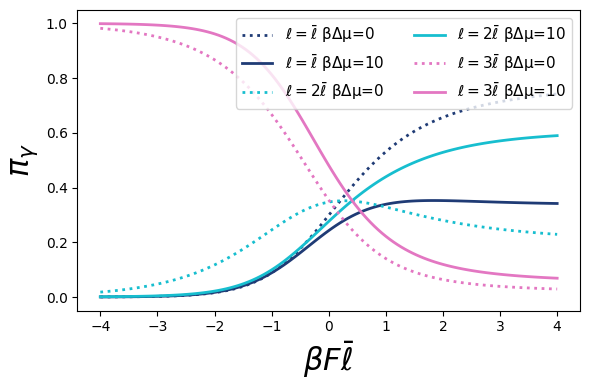

/var/folders/9g/ss87r54j0fvc6tt40lmh_bnc0000gn/T/ipykernel_84329/2799041287.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Mbar[g, d] = np.trapz(integrand, Ls)


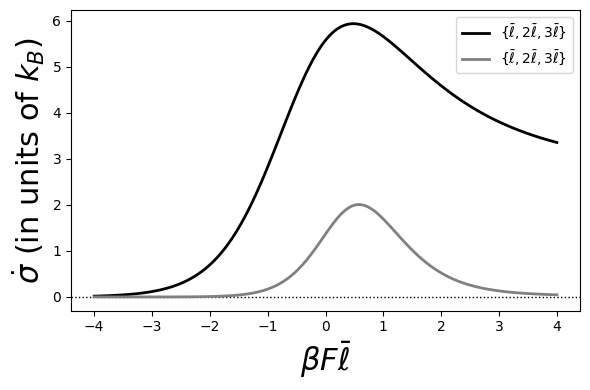

/var/folders/9g/ss87r54j0fvc6tt40lmh_bnc0000gn/T/ipykernel_84329/2799041287.py:176: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Us * P_L, Ls)
/var/folders/9g/ss87r54j0fvc6tt40lmh_bnc0000gn/T/ipykernel_84329/2799041287.py:130: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Mbar[g, d] = np.trapz(integrand, Ls)


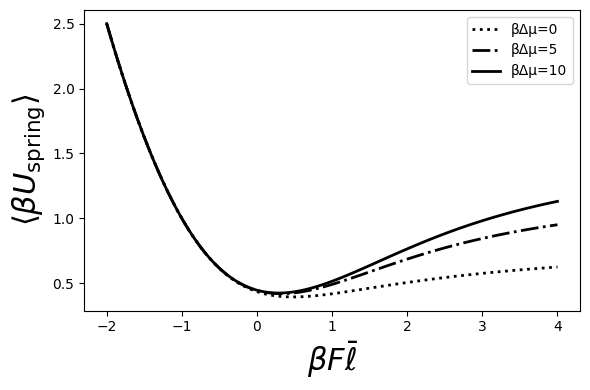

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# =========================
# 1. Global parameters (Just to be safe)
# =========================

beta = 1.0          # β k ℓ̄^2 = 1 → with k=1, ℓ̄=1
k = 1.0
ell_bar = 1.0       # reference length unit
km = 1.0            # bare chemical rate prefactor

# external force range (in units β F ℓ̄ = F since β=ℓ̄=1)
F_vals = np.linspace(-4.0, 4.0, 121)

# driving used for "driven" curves
beta_Dmu_driven = 10.0
Delta_mu_driven = beta_Dmu_driven / beta


# =========================
# 2. Helper functions that depend on ells
# =========================

def ell_gamma(ells, g):
    """Rest length ℓ_γ for internal state index g."""
    return ells[g]

def eps_orientation(g, d):
    """
    Orientation of the 3-state cycle.
    Define states 0->1->2->0 as 'forward' (ε=+1),
    reverse direction as ε=-1, others 0.
    """
    # forward edges: 0→1, 1→2, 2→0
    if d == 0 and g == 1:  # 0->1
        return +1
    if d == 1 and g == 2:  # 1->2
        return +1
    if d == 2 and g == 0:  # 2->0
        return +1
    # backward edges
    if g == 0 and d == 1:  # 1->0
        return -1
    if g == 1 and d == 2:  # 2->1
        return -1
    if g == 2 and d == 0:  # 0->2
        return -1
    return 0

def delta_U(L, ells, g, d):
    """
    Mechanical energy difference between internal states:
      ΔU_{γδ}(L) = (k/2)[(L-ℓ_γ)^2 - (L-ℓ_δ)^2].
    """
    ell_g = ell_gamma(ells, g)
    ell_d = ell_gamma(ells, d)
    return 0.5 * k * ((L - ell_g)**2 - (L - ell_d)**2)

def Z_gamma(F, ells, g):
    """
    Normalisation Z_γ(F) = ∫_0^∞ dL exp{-β[ k/2 (L-ℓ_γ)^2 + F L ]}.
    Closed form from completing the square (Supplement Eq. S5).
    """
    ellg = ell_gamma(ells, g)
    pref = np.sqrt(np.pi) / np.sqrt(2.0 * k * beta)
    expo = np.exp(beta * F * (F - 2.0 * k * ellg) / (2.0 * k))
    arg  = np.sqrt(beta / (2.0 * k)) * (F - k * ellg)
    return pref * expo * erfc(arg)

def P_L_given_gamma(L, ells, g, F):
    """
    Conditional distribution P(L | γ; F) on [0,∞):
      ∝ exp{-β[ k/2 (L-ℓ_γ)^2 + F L ]}.
    """
    Zg = Z_gamma(F, ells, g)
    ellg = ell_gamma(ells, g)
    return np.exp(-beta * (0.5 * k * (L - ellg)**2 + F * L)) / Zg


# =========================
# 3. Equilibrium π_γ(F) (Eq. 4)
# =========================

def pi_equilibrium(F, ells):
    """
    Eq. (4) in the main text: equilibrium internal probabilities π_γ(F)
    for a given set of rest-lengths ells.
    """
    weights = []
    for ellg in ells:
        expo = np.exp(beta * F * (F - 2.0 * k * ellg) / (2.0 * k))
        arg  = np.sqrt(beta/(2.0*k)) * (F - k*ellg)
        w = expo * erfc(arg)
        weights.append(w)
    weights = np.array(weights)
    Z = weights.sum()
    return weights / Z


# =========================
# 4. Coarse-grained M̄(F, Δμ) and stationary π (driven)
# =========================

def coarse_grained_M(F, ells, beta_Dmu, nL=2000):
    """
    Build the coarse-grained 3x3 Markov generator M̄(F, Δμ)
    by integrating over L:
      M̄_{γδ}(F) = ∫_0^∞ dL M_{γδ}(L) P(L | δ; F).
    M_{γδ}(L) = km * exp[βΔμ ε_{γδ}/6] / (1 + exp[β ΔU_{γδ}(L)]).
    """
    n = len(ells)
    Mbar = np.zeros((n, n), dtype=float)

    # L grid for numeric quadrature
    ell_max = np.max(ells)
    Lmax = max(ell_max + 8.0 + 4.0*abs(F), 10.0)  # heuristic, safe-ish
    Ls = np.linspace(0.0, Lmax, nL)

    for d in range(n):
        P_L_d = P_L_given_gamma(Ls, ells, d, F)
        for g in range(n):
            if g == d:
                continue
            e = eps_orientation(g, d)
            dU = delta_U(Ls, ells, g, d)
            M_gd_L = km * np.exp(beta_Dmu * e / 6.0) / (1.0 + np.exp(beta * dU))
            integrand = M_gd_L * P_L_d
            Mbar[g, d] = np.trapz(integrand, Ls)
        # diagonal: ensure each column sums to zero
        Mbar[d, d] = -np.sum(Mbar[:, d]) + Mbar[d, d]

    return Mbar

def stationary_pi(Mbar):
    """
    Stationary distribution π solving M̄ · π = 0, with ∑ π = 1.
    We find the eigenvector with smallest |λ| and normalise.
    """
    w, v = np.linalg.eig(Mbar)
    idx = np.argmin(np.abs(w))
    vec = np.real(v[:, idx])
    pi = vec / np.sum(vec)
    pi = np.clip(pi, 0, None)
    if pi.sum() > 0:
        pi /= pi.sum()
    return pi

def chemical_current(Mbar, pi):
    """
    Chemical current Jchem through the 3-state cycle, e.g. along 0→1→2→0.
    For a ring, the cycle current must be uniform:
      Jchem = M̄_{1,0} π_0 - M̄_{0,1} π_1 (any edge).
    """
    J01 = Mbar[1, 0] * pi[0] - Mbar[0, 1] * pi[1]
    J12 = Mbar[2, 1] * pi[1] - Mbar[1, 2] * pi[2]
    J20 = Mbar[0, 2] * pi[2] - Mbar[2, 0] * pi[0]
    return (J01 + J12 + J20) / 3.0


# =========================
# 5. Average spring energy ⟨U_spring⟩
# =========================

def mean_Uspring_given_gamma(F, ells, g, nL=2000):
    """
    ⟨U_spring | γ, F⟩ = ∫_0^∞ (k/2)(L-ℓ_γ)^2 P(L | γ, F) dL
    """
    ellg = ell_gamma(ells, g)
    ell_max = np.max(ells)
    Lmax = max(ell_max + 8.0 + 4.0*abs(F), 10.0)
    Ls = np.linspace(0.0, Lmax, nL)
    P_L = P_L_given_gamma(Ls, ells, g, F)
    Us = 0.5 * k * (Ls - ellg)**2
    return np.trapz(Us * P_L, Ls)

def average_Uspring(F, ells, pi_gamma):
    """
    ⟨U_spring⟩ = ∑_γ π_γ ⟨U_spring | γ⟩
    """
    U_g = np.array([mean_Uspring_given_gamma(F, ells, g) for g in range(len(ells))])
    return np.dot(pi_gamma, U_g)


# =====================================================
# 6. Fig. 2(a): π_γ(F) for a single cycle (eq vs driven)
# =====================================================

# cycle for panel (a) and (c)
ells_cycle_a = np.array([1.0, 2.0, 3.0])  # {ℓ̄, 2ℓ̄, 3ℓ̄}

pi_eq_a = np.zeros((len(F_vals), len(ells_cycle_a)))
pi_drv_a = np.zeros_like(pi_eq_a)

for iF, F in enumerate(F_vals):
    # equilibrium internal distribution
    pi_eq_a[iF, :] = pi_equilibrium(F, ells_cycle_a)

    # driven internal distribution
    Mbar = coarse_grained_M(F, ells_cycle_a, beta_Dmu_driven)
    pi_drv_a[iF, :] = stationary_pi(Mbar)

# ---- Plot Fig. 2(a) ----
labels_gamma = [r"$\ell=\bar{\ell}$", r"$\ell=2\bar{\ell}$", r"$\ell=3\bar{\ell}$"]
colors = ["#1f3b75", "#17becf", "#e377c2"]

plt.figure(figsize=(6,4))
for g in range(3):
    # equilibrium (dotted)
    plt.plot(F_vals, pi_eq_a[:, g],
             linestyle=":", linewidth=2,
             color=colors[g],
             label=labels_gamma[g] + r" βΔμ=0" )
    # driven (solid)
    plt.plot(F_vals, pi_drv_a[:, g],
             linestyle="-", linewidth=2,
             color=colors[g],
             label=labels_gamma[g] + r" βΔμ=10")

plt.xlabel(r"$\beta F \bar{\ell}$",fontsize=22)
plt.ylabel(r"$\pi_\gamma$",fontsize=22)
plt.legend(fontsize=11, ncol=2)
plt.tight_layout()
plt.savefig("pi_vs_force.pdf")
plt.show()


# =====================================================
# 7. Fig. 2(b): entropy production for TWO cycles
# =====================================================

# define two different internal cycles:
ells_cycle_1 = np.array([1.0, 2.0, 3.0])   # you can replace these with exact paper choices
ells_cycle_2 = np.array([1.0, 3.0, 5.0])   # placeholder second cycle (modify!)

sigma_cycle_1 = np.zeros_like(F_vals)
sigma_cycle_2 = np.zeros_like(F_vals)

for iF, F in enumerate(F_vals):
    # cycle 1
    Mbar1 = coarse_grained_M(F, ells_cycle_1, beta_Dmu_driven)
    pi1 = stationary_pi(Mbar1)
    J1 = chemical_current(Mbar1, pi1)
    sigma_cycle_1[iF] = beta * Delta_mu_driven * J1

    # cycle 2
    Mbar2 = coarse_grained_M(F, ells_cycle_2, beta_Dmu_driven)
    pi2 = stationary_pi(Mbar2)
    J2 = chemical_current(Mbar2, pi2)
    sigma_cycle_2[iF] = beta * Delta_mu_driven * J2

# ---- Plot Fig. 2(b) ----
plt.figure(figsize=(6,4))
plt.axhline(0.0, linestyle=":", color="k", linewidth=1)

plt.plot(F_vals, sigma_cycle_1, label=r"$\{\bar{\ell},2\bar{\ell},3\bar{\ell} \}$", linewidth=2,color="black")
plt.plot(F_vals, sigma_cycle_2, label=r"$\{\bar{\ell},2\bar{\ell},3\bar{\ell} \}$", linewidth=2,color="grey")

plt.xlabel(r"$\beta F \bar{\ell}$",fontsize=22)
plt.ylabel(r"$\dot{\sigma}$ (in units of $k_B$)",fontsize=22)
plt.legend()
plt.tight_layout()
plt.savefig("entrp prod.pdf")
plt.show()


# =====================================================
# 8. Fig. 2(c): ⟨β U_spring⟩ for cycle (a) (eq vs driven)
# =====================================================

F_vals = np.linspace(-2.0, 4.0, 121)

beta_Us_eq = np.zeros_like(F_vals)
beta_Us_drv = np.zeros_like(F_vals)
beta_Us_drv2 = np.zeros_like(F_vals)

for iF, F in enumerate(F_vals):
    # eq: use π_eq from Eq.(4)
    pi_eq = pi_equilibrium(F, ells_cycle_a)
    U_eq = average_Uspring(F, ells_cycle_a, pi_eq)
    beta_Us_eq[iF] = beta * U_eq

    # driven: use π_drv from coarse-grained dynamics
    Mbar = coarse_grained_M(F, ells_cycle_a, beta_Dmu_driven)
    pi_drv = stationary_pi(Mbar)
    U_drv = average_Uspring(F, ells_cycle_a, pi_drv)
    beta_Us_drv[iF] = beta * U_drv
    
    Mbar2 = coarse_grained_M(F, ells_cycle_a, 5)
    pi_drv2 = stationary_pi(Mbar2)
    U_drv = average_Uspring(F, ells_cycle_a, pi_drv2)
    beta_Us_drv2[iF] = beta * U_drv
    
    

# ---- Plot Fig. 2(c) ----
plt.figure(figsize=(6,4))
plt.plot(F_vals, beta_Us_eq, linestyle=":", linewidth=2, label=r"βΔμ=0",color="black")
plt.plot(F_vals, beta_Us_drv2, linestyle="dashdot", linewidth=2, label=r"βΔμ=5",color="black")
plt.plot(F_vals, beta_Us_drv, linestyle="-", linewidth=2, label=r"βΔμ=10",color="black")


plt.xlabel(r"$\beta F \bar{\ell}$", fontsize=22)
plt.ylabel(r"$\langle \beta U_{\rm spring} \rangle$",fontsize =22)
plt.legend()
plt.tight_layout()
plt.savefig("U_spring.pdf")
plt.show()


/var/folders/9g/ss87r54j0fvc6tt40lmh_bnc0000gn/T/ipykernel_84329/4110267186.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  w = np.trapz(rate_offdiag(L1, ells1, g1p, g1, beta_Dmu1) * p, x)
/var/folders/9g/ss87r54j0fvc6tt40lmh_bnc0000gn/T/ipykernel_84329/4110267186.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  w = np.trapz(rate_offdiag(L2, ells2, g2p, g2, beta_Dmu2) * p, x)


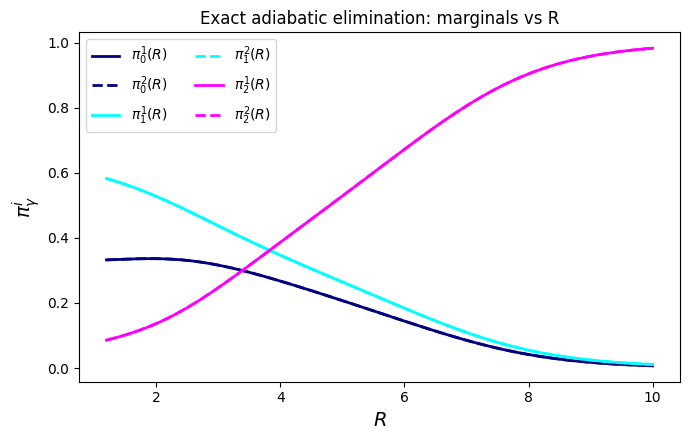

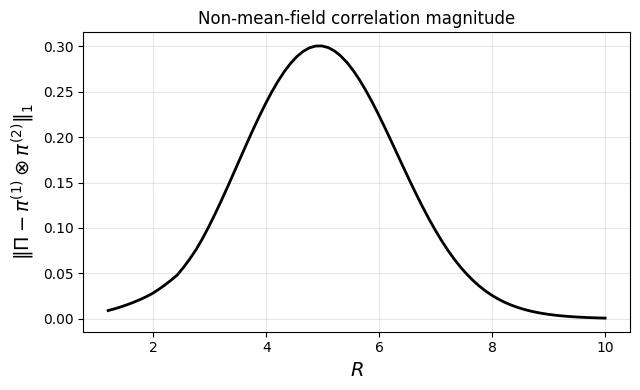

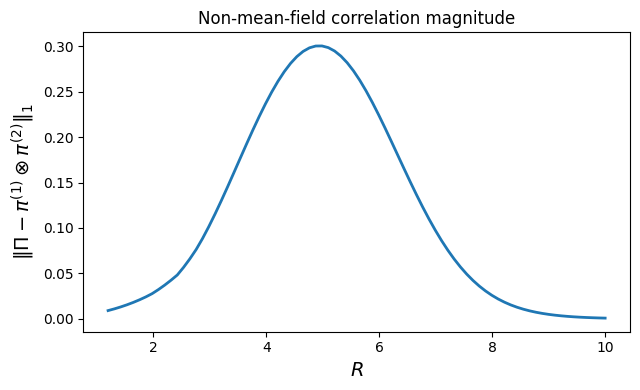

In [ ]:


# =========================
# Parameters
# =========================
n = 3

ells1 = np.array([1.0, 2.0, 3.0])
ells2 = np.array([1.0, 2.0, 3.0])   # change e.g. ells2 = ells1 + 0.5 for shift

beta_Dmu1 = 10.0
beta_Dmu2 = 10.0

# Sweep range
R_vals = np.linspace(1.2, 10.0, 80)

# =========================
# Ring orientation and rates
# =========================
def eps_ring(g, d, n=3):
    if g == (d + 1) % n: return +1
    if g == (d - 1) % n: return -1
    return 0

def deltaU(L, ells, g, d):
    # energy difference (not multiplied by beta)
    return 0.5 * k * ((L - ells[g])**2 - (L - ells[d])**2)

def rate_offdiag(L, ells, g, d, beta_Dmu):
    """Off-diagonal rate d->g; 0 if not neighbour or g==d."""
    if g == d:
        return np.zeros_like(L, dtype=float)
    e = eps_ring(g, d, len(ells))
    if e == 0:
        return np.zeros_like(L, dtype=float)
    drive_den = 2.0 * len(ells)  # for n=3: 6
    dU_beta = beta * deltaU(L, ells, g, d)
    return km * np.exp(beta_Dmu * e / drive_den) / (1.0 + np.exp(dU_beta))

# =========================
# Mechanics: p_ss(x | g1,g2) for pinned ends
# =========================
def p_ss_x(x, R, g1, g2):
    ell1 = ells1[g1]
    ell2 = ells2[g2]
    mu = 0.5 * (R + ell1 - ell2)
    a = np.sqrt(beta * k)
    Z = (np.sqrt(np.pi)/(2*a)) * (erf(a*(R-mu)) + erf(a*mu))
    # Z should be positive for sensible params; guard anyway
    if (Z <= 0) or (not np.isfinite(Z)):
        return np.zeros_like(x)
    return np.exp(-beta * k * (x - mu)**2) / Z

# =========================
# Indexing for 9-state joint system
# =========================
def idx(g1, g2):
    return n * g1 + g2

# =========================
# Build 9x9 generator G(R)
# =========================
def build_generator_9(R, nX=900):
    x = np.linspace(0.0, R, nX)
    L1 = x
    L2 = R - x

    G = np.zeros((n*n, n*n), dtype=float)

    for g1 in range(n):
        for g2 in range(n):
            s_from = idx(g1, g2)
            p = p_ss_x(x, R, g1, g2)

            # Spring 1 transitions: (g1,g2)->(g1',g2) with g1' neighbours
            for g1p in ((g1 + 1) % n, (g1 - 1) % n):
                w = np.trapz(rate_offdiag(L1, ells1, g1p, g1, beta_Dmu1) * p, x)
                G[idx(g1p, g2), s_from] += w

            # Spring 2 transitions: (g1,g2)->(g1,g2') with g2' neighbours
            for g2p in ((g2 + 1) % n, (g2 - 1) % n):
                w = np.trapz(rate_offdiag(L2, ells2, g2p, g2, beta_Dmu2) * p, x)
                G[idx(g1, g2p), s_from] += w

            # Diagonal for probability conservation (columns sum to 0)
            G[s_from, s_from] = -np.sum(G[:, s_from]) 

    return G

def stationary_distribution(G):
    n_states = G.shape[0]
    # Replace the last row with the normalization condition: sum(pi) = 1
    A = np.copy(G)
    A[-1, :] = 1.0
    b = np.zeros(n_states)
    b[-1] = 1.0
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        # Fallback to least squares if singular
        return np.linalg.lstsq(A, b, rcond=None)[0]

def marginals_from_Pi(Pi):
    Pi_mat = Pi.reshape((n, n))  # Pi[g1,g2]
    pi1 = Pi_mat.sum(axis=1)     # sum over g2
    pi2 = Pi_mat.sum(axis=0)     # sum over g1
    return pi1, pi2, Pi_mat

# Optional: correlation magnitude ||Pi - pi1⊗pi2||_1
def corr_L1(Pi_mat, pi1, pi2):
    prod = np.outer(pi1, pi2)
    return np.sum(np.abs(Pi_mat - prod))

# =========================
# Sweep R, compute Pi_ss(R), extract marginals, plot
# =========================
pi1_R = np.zeros((len(R_vals), n))
pi2_R = np.zeros_like(pi1_R)
corr_R = np.zeros(len(R_vals))  # optional diagnostic

for i, R in enumerate(R_vals):
    G = build_generator_9(R, nX=900)
    Pi = stationary_distribution(G)
    pi1, pi2, Pi_mat = marginals_from_Pi(Pi)

    pi1_R[i, :] = pi1
    pi2_R[i, :] = pi2
    corr_R[i] = corr_L1(Pi_mat, pi1, pi2)

colors = ["navy", "cyan", "magenta"]
# --- Plot marginals vs R ---
plt.figure(figsize=(7, 4.5))
for g in range(n):
    plt.plot(R_vals, pi1_R[:, g], linewidth=2, label=fr"$\pi^{(1)}_{{{g}}}(R)$",color=colors[g])
    plt.plot(R_vals, pi2_R[:, g], linewidth=2, linestyle="--", label=fr"$\pi^{(2)}_{{{g}}}(R)$",color=colors[g])
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\pi^{i}_{\gamma}$", fontsize=14)
plt.title("Exact adiabatic elimination: marginals vs R", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

# 2) Correlation Plot
plt.figure(figsize=(6.5, 4.0))
plt.plot(R_vals, corr_R, linewidth=2, color='black')
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\|\Pi - \pi^{(1)}\otimes\pi^{(2)}\|_1$", fontsize=14)
plt.title("Non-mean-field correlation magnitude", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()










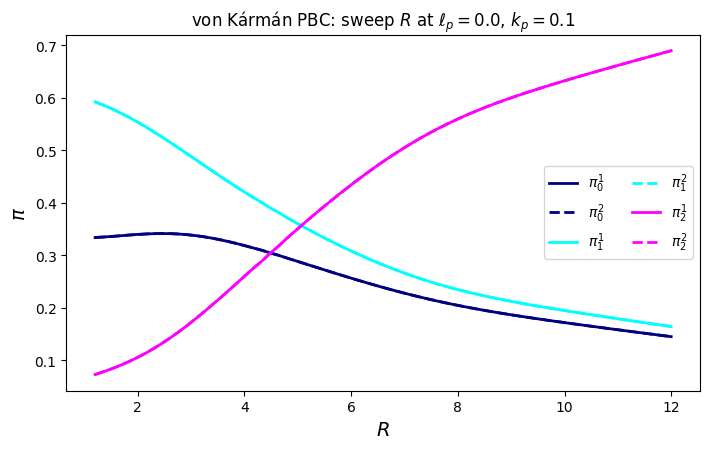

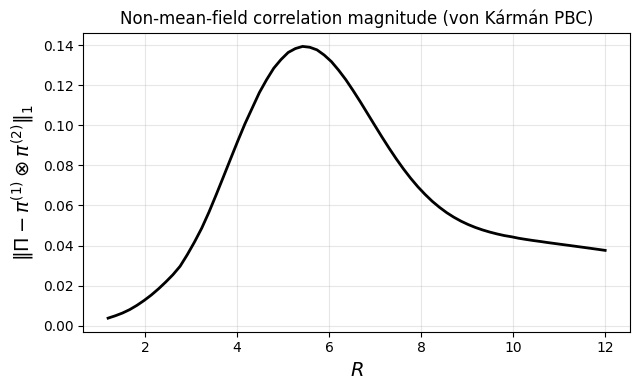

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Global parameters
# =========================
beta = 1.0
k = 1.0
km = 1.0
n = 3

ells1 = np.array([1.0, 2.0, 3.0])
ells2 = np.array([1.0, 2.0, 3.0])  # can shift/change

beta_Dmu1 = 10.0
beta_Dmu2 = 10.0

# =========================
# Ring orientation and rates (nearest-neighbour only)
# =========================
def eps_ring(g, d, n):
    if g == (d + 1) % n: return +1
    if g == (d - 1) % n: return -1
    return 0

def deltaU(L, ells, g, d):
    return 0.5 * k * ((L - ells[g])**2 - (L - ells[d])**2)

def rate_offdiag(L, ells, g, d, beta_Dmu):
    """Off-diagonal rate d->g; nearest-neighbour ring only."""
    if g == d:
        return np.zeros_like(L, dtype=float)
    e = eps_ring(g, d, len(ells))
    if e == 0:
        return np.zeros_like(L, dtype=float)
    drive_den = 2.0 * len(ells)  # =6 for n=3
    dU_beta = beta * deltaU(L, ells, g, d)
    return km * np.exp(beta_Dmu * e / drive_den) / (1.0 + np.exp(dU_beta))

# =========================
# Indexing for joint 9-state system
# =========================
def idx(g1, g2):
    return n*g1 + g2

# =========================
# Build generator G(R, lp, kp) under von Kármán PBC:
# x3 = x0 + R => Lp = R - L1 - L2 >= 0
# Domain: triangle L1>=0, L2>=0, L1+L2<=R
# =========================
def build_G_vonkarman(R, lp, kp, Ngrid=260):
    # grids on [0,R]
    L1_grid = np.linspace(0.0, R, Ngrid)
    L2_grid = np.linspace(0.0, R, Ngrid)
    dL1 = L1_grid[1] - L1_grid[0]
    dL2 = L2_grid[1] - L2_grid[0]

    L1, L2 = np.meshgrid(L1_grid, L2_grid, indexing="ij")
    mask = (L1 + L2 <= R)
    Lp = R - L1 - L2  # passive segment length (>=0 on mask)

    G = np.zeros((n*n, n*n), dtype=float)

    for g1 in range(n):
        for g2 in range(n):
            s_from = idx(g1, g2)

            U = (0.5*k*(L1 - ells1[g1])**2
               + 0.5*k*(L2 - ells2[g2])**2
               + 0.5*kp*(Lp - lp)**2)

            W = np.exp(-beta * U) * mask
            Z = np.sum(W) * dL1 * dL2
            if (Z <= 0) or (not np.isfinite(Z)):
                # leave column zeros (rare unless R tiny)
                continue

            # marginals p(L1|g1,g2), p(L2|g1,g2)
            pL1 = (np.sum(W, axis=1) * dL2) / Z  # shape (Ngrid,)
            pL2 = (np.sum(W, axis=0) * dL1) / Z  # shape (Ngrid,)

            # spring 1: integrate rates over pL1
            for g1p in ((g1+1) % n, (g1-1) % n):
                rates = rate_offdiag(L1_grid, ells1, g1p, g1, beta_Dmu1)
                w = np.sum(rates * pL1) * dL1
                G[idx(g1p, g2), s_from] += w

            # spring 2: integrate rates over pL2
            for g2p in ((g2+1) % n, (g2-1) % n):
                rates = rate_offdiag(L2_grid, ells2, g2p, g2, beta_Dmu2)
                w = np.sum(rates * pL2) * dL2
                G[idx(g1, g2p), s_from] += w

            # diagonal: columns sum to zero
            G[s_from, s_from] = -np.sum(G[:, s_from])

    return G

def stationary_distribution(G):
    # robust nullvector using SVD
    _, _, vt = np.linalg.svd(G)
    v = vt[-1, :]
    if v.sum() < 0:
        v = -v
    v = np.clip(v, 0, None)
    if v.sum() == 0:
        v = np.ones_like(v)
    return v / v.sum()

def marginals_from_Pi(Pi):
    Pi_mat = Pi.reshape((n, n))  # Pi[g1,g2]
    pi1 = Pi_mat.sum(axis=1)
    pi2 = Pi_mat.sum(axis=0)
    return pi1, pi2, Pi_mat

# cycle currents along edge 0->1 (summed over the other spring)
def J1_edge01(G, Pi):
    J = 0.0
    for g2 in range(n):
        s0 = idx(0, g2); s1 = idx(1, g2)
        J += G[s1, s0]*Pi[s0] - G[s0, s1]*Pi[s1]
    return J

def J2_edge01(G, Pi):
    J = 0.0
    for g1 in range(n):
        s0 = idx(g1, 0); s1 = idx(g1, 1)
        J += G[s1, s0]*Pi[s0] - G[s0, s1]*Pi[s1]
    return J

# =========================
# Slice helpers
# =========================
def sweep_R(R_vals, lp, kp, Ngrid=260):
    pi1 = np.zeros((len(R_vals), n))
    pi2 = np.zeros_like(pi1)
    J1 = np.zeros(len(R_vals))
    J2 = np.zeros(len(R_vals))

    for i, R in enumerate(R_vals):
        G = build_G_vonkarman(R, lp, kp, Ngrid=Ngrid)
        Pi = stationary_distribution(G)
        p1, p2, _ = marginals_from_Pi(Pi)
        pi1[i] = p1
        pi2[i] = p2
        J1[i] = J1_edge01(G, Pi)
        J2[i] = J2_edge01(G, Pi)
    return pi1, pi2, J1, J2

def sweep_lp(lp_vals, R, kp, Ngrid=260):
    pi1 = np.zeros((len(lp_vals), n))
    pi2 = np.zeros_like(pi1)
    J1 = np.zeros(len(lp_vals))
    J2 = np.zeros(len(lp_vals))

    for i, lp in enumerate(lp_vals):
        G = build_G_vonkarman(R, lp, kp, Ngrid=Ngrid)
        Pi = stationary_distribution(G)
        p1, p2, _ = marginals_from_Pi(Pi)
        pi1[i] = p1
        pi2[i] = p2
        J1[i] = J1_edge01(G, Pi)
        J2[i] = J2_edge01(G, Pi)
    return pi1, pi2, J1, J2

def sweep_kp(kp_vals, R, lp, Ngrid=260):
    pi1 = np.zeros((len(kp_vals), n))
    pi2 = np.zeros_like(pi1)
    J1 = np.zeros(len(kp_vals))
    J2 = np.zeros(len(kp_vals))

    for i, kp in enumerate(kp_vals):
        G = build_G_vonkarman(R, lp, kp, Ngrid=Ngrid)
        Pi = stationary_distribution(G)
        p1, p2, _ = marginals_from_Pi(Pi)
        pi1[i] = p1
        pi2[i] = p2
        J1[i] = J1_edge01(G, Pi)
        J2[i] = J2_edge01(G, Pi)
    return pi1, pi2, J1, J2

def sweep_R(R_vals, lp, kp, Ngrid=260):
    pi1 = np.zeros((len(R_vals), n))
    pi2 = np.zeros_like(pi1)
    J1  = np.zeros(len(R_vals))
    J2  = np.zeros(len(R_vals))
    corr = np.zeros(len(R_vals))   # NEW

    for i, R in enumerate(R_vals):
        G  = build_G_vonkarman(R, lp, kp, Ngrid=Ngrid)
        Pi = stationary_distribution(G)

        p1, p2, Pi_mat = marginals_from_Pi(Pi)   # keep Pi_mat now
        pi1[i] = p1
        pi2[i] = p2

        J1[i] = J1_edge01(G, Pi)
        J2[i] = J2_edge01(G, Pi)

        corr[i] = corr_L1(Pi_mat, p1, p2)        # NEW

    return pi1, pi2, J1, J2, corr
# =========================
# Example: slices
# =========================
# 1) Sweep R at fixed lp,kp
'''plt.figure(figsize=(7, 4.5))
for g in range(n):
    plt.plot(R_vals, pi1_R[:, g], linewidth=2, label=fr"$\pi^{(1)}_{{{g}}}(R)$",color=colors[g])
    plt.plot(R_vals, pi2_R[:, g], linewidth=2, linestyle="--", label=fr"$\pi^{(2)}_{{{g}}}(R)$",color=colors[g])
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\pi^{i}_{\gamma}$", fontsize=14)
plt.title("Exact adiabatic elimination: marginals vs R", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

# --- Optional: plot correlation strength vs R ---
plt.figure(figsize=(6.5, 4.0))
plt.plot(R_vals, corr_R, linewidth=2)
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\|\Pi - \pi^{(1)}\otimes\pi^{(2)}\|_1$", fontsize=14)
plt.title("Non-mean-field correlation magnitude", fontsize=12)
plt.tight_layout()
plt.show()'''
colors = ["navy", "cyan", "magenta"]

R_vals = np.linspace(1.2, 12.0, 70)
# effectively ive absorbed it in to the ring size! so l'_{passive} = R - lp 
lp0 = 0.0
kp0 = 0.1

pi1R, pi2R, J1R, J2R, corrR = sweep_R(R_vals, lp0, kp0, Ngrid=260)

# (your marginals plot as before...)
plt.figure(figsize=(7.2, 4.6))
for g in range(n):
    plt.plot(R_vals, pi1R[:, g], linewidth=2, label=fr"$\pi^{(1)}_{g}$", color=colors[g])
    plt.plot(R_vals, pi2R[:, g], linewidth=2, linestyle="--", label=fr"$\pi^{(2)}_{g}$", color=colors[g])
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\pi$", fontsize=14)
plt.title(fr"von Kármán PBC: sweep $R$ at $\ell_p={lp0}$, $k_p={kp0}$", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

# 2) Correlation Plot
plt.figure(figsize=(6.5, 4.0))
plt.plot(R_vals, corrR, linewidth=2, color='black')
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\|\Pi - \pi^{(1)}\otimes\pi^{(2)}\|_1$", fontsize=14)
plt.title("Non-mean-field correlation magnitude (von Kármán PBC)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




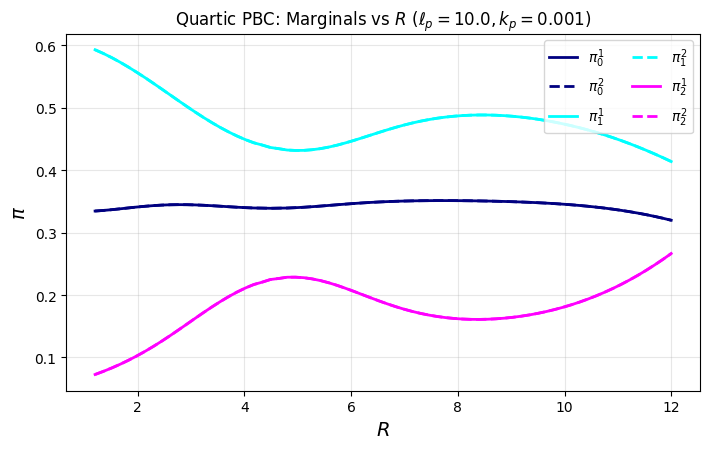

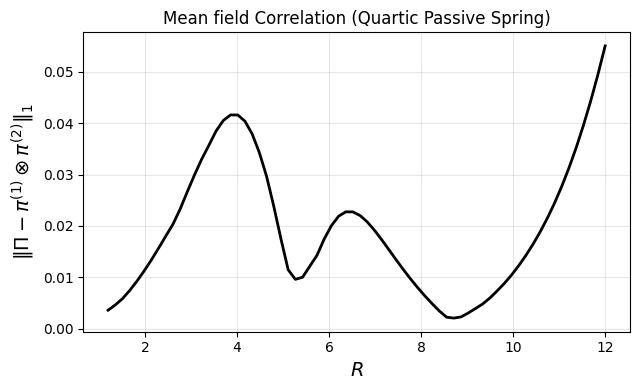

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Global parameters
# =========================

# Rest lengths (identical springs for standard marginal comparison)
ells1 = np.array([1.0, 2.0, 3.0])
ells2 = np.array([1.0, 2.0, 3.0]) 

beta_Dmu1 = 10.0
beta_Dmu2 = 10.0

# =========================
# Physics Helpers
# =========================



# =========================
# Stationary Solver (SVD Robust)
# =========================
def stationary_distribution(G):
    _, _, vt = np.linalg.svd(G)
    v = vt[-1, :]
    if v.sum() < 0: v = -v
    v = np.clip(v, 0, None)
    if v.sum() == 0: v = np.ones_like(v)
    return v / v.sum()

# =========================
# Build Generator with Quartic Passive Spring
# =========================
def build_G_quartic_pbc(R, lp, kp, Ngrid=260):
    L1_grid = np.linspace(0.0, R, Ngrid)
    L2_grid = np.linspace(0.0, R, Ngrid)
    dL1 = L1_grid[1] - L1_grid[0]
    dL2 = L2_grid[1] - L2_grid[0]

    L1, L2 = np.meshgrid(L1_grid, L2_grid, indexing="ij")
    mask = (L1 + L2 <= R)
    Lp = R - L1 - L2 

    G = np.zeros((n*n, n*n), dtype=float)

    for g1 in range(n):
        for g2 in range(n):
            s_from = idx(g1, g2)

            # Potential: Active (Harmonic) + Passive (QUARTIC)
            # U = U_act1 + U_act2 + kp*(Lp^2 - lp^2)^2
            U = (0.5*k*(L1 - ells1[g1])**2
               + 0.5*k*(L2 - ells2[g2])**2
               + kp * (Lp**2 - lp**2)**2)

            W = np.exp(-beta * U) * mask
            Z = np.sum(W) * dL1 * dL2
            if Z <= 0: continue

            # Marginals for integrating rates
            pL1 = (np.sum(W, axis=1) * dL2) / Z 
            pL2 = (np.sum(W, axis=0) * dL1) / Z 

            for g1p in ((g1+1)%n, (g1-1)%n):
                rates = rate_offdiag(L1_grid, ells1, g1p, g1, beta_Dmu1)
                G[idx(g1p, g2), s_from] += np.sum(rates * pL1) * dL1

            for g2p in ((g2+1)%n, (g2-1)%n):
                rates = rate_offdiag(L2_grid, ells2, g2p, g2, beta_Dmu2)
                G[idx(g1, g2p), s_from] += np.sum(rates * pL2) * dL2

            G[s_from, s_from] = -np.sum(G[:, s_from])
    return G

# =========================
# Sweep Logic
# =========================
def sweep_R_quartic(R_vals, lp, kp, Ngrid=260):
    pi1 = np.zeros((len(R_vals), n))
    pi2 = np.zeros_like(pi1)
    corr = np.zeros(len(R_vals))

    for i, R in enumerate(R_vals):
        G  = build_G_quartic_pbc(R, lp, kp, Ngrid=Ngrid)
        Pi = stationary_distribution(G)

        # Reshape to 3x3 to find marginals
        Pi_mat = Pi.reshape((n, n))
        p1 = Pi_mat.sum(axis=1) # S1 marginal
        p2 = Pi_mat.sum(axis=0) # S2 marginal
        
        pi1[i] = p1
        pi2[i] = p2
        corr[i] = corr_L1(Pi_mat, p1, p2)

    return pi1, pi2, corr

# =========================
# Execution & Plotting
# =========================
colors = ["navy", "cyan", "magenta"]
R_vals = np.linspace(1.2, 12.0, 70)
lp0 = 10.0
kp0 = 0.001 # Quartic stiffness parameter

pi1R, pi2R, corrR = sweep_R_quartic(R_vals, lp0, kp0, Ngrid=260)

# 1) Marginals Plot
plt.figure(figsize=(7.2, 4.6))
for g in range(n):
    plt.plot(R_vals, pi1R[:, g], linewidth=2, label=fr"$\pi^{(1)}_{g}$", color=colors[g])
    plt.plot(R_vals, pi2R[:, g], linewidth=2, linestyle="--", label=fr"$\pi^{(2)}_{g}$", color=colors[g])

plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\pi$", fontsize=14)
plt.title(fr"Quartic PBC: Marginals vs $R$ ($\ell_p={lp0}, k_p={kp0}$)", fontsize=12)
plt.legend(ncol=2, fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Correlation Plot
plt.figure(figsize=(6.5, 4.0))
plt.plot(R_vals, corrR, linewidth=2, color='black')
plt.xlabel(r"$R$", fontsize=14)
plt.ylabel(r"$\|\Pi - \pi^{(1)}\otimes\pi^{(2)}\|_1$", fontsize=14)
plt.title("Mean field Correlation (Quartic Passive Spring)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

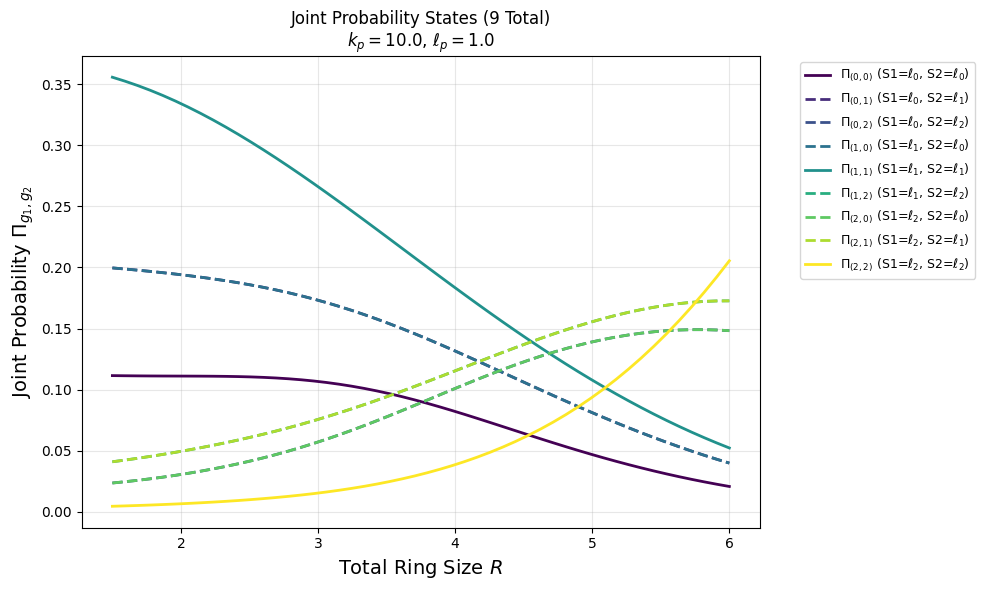

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Parameters
# =============================================================================
beta = 1.0
k = 1.0
km = 1.0
n = 3

# Rest lengths for the 3 states of each spring
ells1 = np.array([1.0, 2.0, 3.0])
ells2 = np.array([1.0, 2.0, 3.0]) 

# Driving Affinity
beta_Dmu1 = 10.0
beta_Dmu2 = 10.0

def eps_ring(g, d, n=3):
    if g == (d + 1) % n: return +1
    if g == (d - 1) % n: return -1
    return 0

def rate_offdiag(L, ells, g, d, beta_Dmu):
    if g == d: return np.zeros_like(L)
    e = eps_ring(g, d, len(ells))
    if e == 0: return np.zeros_like(L)
    dU = 0.5 * k * ((L - ells[g])**2 - (L - ells[d])**2)
    return km * np.exp(beta_Dmu * e / 6.0) / (1.0 + np.exp(beta * dU))

def idx(g1, g2):
    return n * g1 + g2

# =============================================================================
# Stationary Solver (Robust Version)
# =============================================================================
def stationary_distribution(G):
    n_states = G.shape[0]
    A = np.copy(G)
    # Replace last row with normalization condition sum(Pi) = 1
    A[-1, :] = 1.0
    b = np.zeros(n_states)
    b[-1] = 1.0
    try:
        sol = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        sol = np.linalg.lstsq(A, b, rcond=None)[0]
    return np.clip(sol, 0, None) / np.sum(np.clip(sol, 0, None))

# =============================================================================
# Build Generator for PBC Case
# =============================================================================
def build_G_joint(R, lp, kp, Ngrid=150):
    L1_grid = np.linspace(0.01, R, Ngrid)
    L2_grid = np.linspace(0.01, R, Ngrid)
    dL = L1_grid[1] - L1_grid[0]
    
    L1, L2 = np.meshgrid(L1_grid, L2_grid, indexing='ij')
    mask = (L1 + L2 < R)
    Lp = R - L1 - L2 # Length of passive spring
    
    G = np.zeros((n*n, n*n))
    
    for g1 in range(n):
        for g2 in range(n):
            s_from = idx(g1, g2)
            
            # Local potential for these states
            U = (0.5*k*(L1 - ells1[g1])**2 + 
                 0.5*k*(L2 - ells2[g2])**2 + 
                 0.5*kp*(Lp - lp)**2)
            
            W = np.exp(-beta * U) * mask
            Z = np.sum(W) * (dL**2)
            
            if Z <= 0: continue
            
            # Prob densities p(L1) and p(L2)
            pL1 = (np.sum(W, axis=1) * dL) / Z
            pL2 = (np.sum(W, axis=0) * dL) / Z
            
            # Spring 1 Transitions
            for g1p in [(g1+1)%n, (g1-1)%n]:
                w = np.sum(rate_offdiag(L1_grid, ells1, g1p, g1, beta_Dmu1) * pL1) * dL
                G[idx(g1p, g2), s_from] += w
                
            # Spring 2 Transitions
            for g2p in [(g2+1)%n, (g2-1)%n]:
                w = np.sum(rate_offdiag(L2_grid, ells2, g2p, g2, beta_Dmu2) * pL2) * dL
                G[idx(g1, g2p), s_from] += w
                
            G[s_from, s_from] = -np.sum(G[:, s_from])
    return G

# =============================================================================
# Execution and Plotting
# =============================================================================
R_vals = np.linspace(1.5, 6.0, 50)
lp = 1.0
kp = 10.0 # Interaction strength

# To store all 9 joint probabilities
joint_probs = np.zeros((len(R_vals), n*n))

for i, R in enumerate(R_vals):
    G = build_G_joint(R, lp, kp)
    joint_probs[i, :] = stationary_distribution(G)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, n*n))

for g1 in range(n):
    for g2 in range(n):
        s = idx(g1, g2)
        label = fr"$\Pi_{{({g1},{g2})}}$ (S1=$\ell_{g1}$, S2=$\ell_{g2}$)"
        # Use different line styles to help distinguish overlapping curves
        linestyle = '-' if g1 == g2 else '--'
        plt.plot(R_vals, joint_probs[:, s], label=label, color=colors[s], lw=2, ls=linestyle)

plt.xlabel(r"Total Ring Size $R$", fontsize=14)
plt.ylabel(r"Joint Probability $\Pi_{g_1, g_2}$", fontsize=14)
plt.title(f"Joint Probability States (9 Total)\n$k_p={kp}$, $\ell_p={lp}$", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Active Solid  code 

I will start by coding from the paper and trying to replicate the plots perhaps after I can start messing a round. Just to get started its worth writing down important equations down 



In [3]:
"""
TCAS Active Solid (1D ring) simulator
------------------------------------
Goal: reproduce Fig. 4 of Cocconi/Chatzittofi/Golestanian (arXiv:2506.18000v1).

Model (from Eq. (5) + Fig. 4 caption):
- N active elastic elements (springs) on a ring of total length R
- Bond lengths L_i > 0 with sum_i L_i = R (conserved)
- Each spring has internal state gamma_i in {A,B,C,...} with rest length ell_gamma
- Mechanical dynamics (overdamped + conserved noise):
    dL_i = 2 mu_p * sum_j K_ij * (-∂_{L_j} U) dt + sqrt(4 mu_p / beta) * eta_i
  where K = I - (1/2)(shift+shift^-1) on the ring, and cov(eta)=K δ(t-t')
  We implement eta_i via differences of iid Gaussians: eta_i ∝ (ζ_{i+1}-ζ_i)/sqrt(2)
- Energy per bond:
    U_i = 1/2 k (L_i - ell_{gamma_i})^2 + U_WCA(L_i; sigma=a, epsilon=eps_rep)
- Chemical jumps per spring (3-state ring by default), with local detailed balance:
    rate(delta->gamma) = k_m * exp(beta*Δμ*ε/6) / (1 + exp(beta*ΔU_{γδ}(L_i)))
  with ΔU_{γδ}(L) = 1/2 k[(L-ell_γ)^2 - (L-ell_δ)^2] + (U_ell[γ]-U_ell[δ])
- Because rates depend on L(t), we use thinning:
    λ̄_tot = N * 2 k_m cosh(beta*Δμ/6)  (safe bound since logistic ≤ 1)

Observables for Fig. 4:
(a) entropy production per bead: σdot_tot/N = beta*Δμ * J_chem
    We estimate J_chem as net signed steps / (n_states * T_obs * N).
(b) “effective pressure”: paper refers to [71] for exact definition.
    We provide a reasonable proxy: p_eff ≈ <∂U/∂L> (conjugate to R constraint).
(c) conditional current for a tagged spring vs its length: J(L_bin)

Notes:
- Uses adaptive mech timestep: dt_small when any L is near WCA core; dt_big otherwise.
- Includes tqdm progress bars if installed.

"""

import numpy as np
import matplotlib.pyplot as plt

# tqdm optional
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


# ============================================================
# Parameters (match Fig. 4 caption defaults)
# ============================================================

class Params:
    # Units: ellbar = 1
    ell0   = 1.0          # \bar{ell}
    beta   = 1.0
    km     = 1.0          # microscopic chemical rate
    delmu  = 10.0         # Δμ (paper uses beta*Δμ = 10; here beta=1)
    mu_p   = 0.01         # caption: mu_p = 0.01 * beta * km * ellbar^2 -> 0.01
    eps_rep = 1.0         # caption: beta*epsilon = 1 -> epsilon=1 if beta=1
    a      = 0.1          # WCA length scale sigma=a = 0.1 ellbar
    # internal states (3-state ring): ell_A=0.9, ell_B=1.0, ell_C=1.1
    ell_states = np.array([0.9, 1.0, 1.1]) * ell0
    U_ell   = None        # can add internal energies if needed
    drive_den = 6.0       # for 3-state convention: beta*Δμ/6
    # numerical safety
    L_floor = 1e-9

P = Params()


# ============================================================
# Helpers: internal transitions
# ============================================================

def wca_cutoff(sigma):
    return (2.0 ** (1.0 / 6.0)) * sigma

def wca_force_vec(L, eps_rep=1.0, sigma=0.1):
    """
    Vectorized WCA force magnitude: F_rep = -dU/dL.
    Returns array same shape as L.
    """
    rc = wca_cutoff(sigma)
    L = np.asarray(L)
    F = np.zeros_like(L, dtype=float)

    # avoid division problems
    mask = (L > 0.0) & (L < rc)
    if np.any(mask):
        x = sigma / L[mask]
        x6 = x**6
        x12 = x6**2
        F[mask] = 24.0 * eps_rep * (2.0 * x12 - x6) / L[mask]

    # if L<=0 (shouldn’t happen with L_floor), treat huge repulsion
    F[L <= 0.0] = 1e12
    return F

def delta_U_vec(L, ell_gamma, ell_delta, k, U_gamma=0.0, U_delta=0.0):
    """
    Vectorized ΔU_{γδ}(L) for rest-length changes at fixed L.
    """
    return 0.5 * k * ((L - ell_gamma)**2 - (L - ell_delta)**2) + (U_gamma - U_delta)

def rates_plus_minus(L, delta, *, km, beta, delmu, k, ell_states, U_ell=None, drive_den=6.0):
    """
    For each spring i:
      delta[i] is current state
      plus target: (delta+1)%n
      minus target: (delta-1)%n
    Returns r_plus, r_minus arrays length N, and eps signs (+1/-1).
    """
    n_states = len(ell_states)
    delta = np.asarray(delta, dtype=int)
    L = np.asarray(L, dtype=float)

    plus = (delta + 1) % n_states
    minus = (delta - 1) % n_states

    ell_d = ell_states[delta]
    ell_p = ell_states[plus]
    ell_m = ell_states[minus]

    if U_ell is None:
        U_ell = np.zeros(n_states)
    U_d = U_ell[delta]
    U_p = U_ell[plus]
    U_m = U_ell[minus]

    dU_p = delta_U_vec(L, ell_p, ell_d, k, U_p, U_d)
    dU_m = delta_U_vec(L, ell_m, ell_d, k, U_m, U_d)

    # local detailed balance form used in your code/paper
    pref_p = np.exp(beta * delmu / drive_den)   # eps=+1
    pref_m = np.exp(-beta * delmu / drive_den)  # eps=-1

    r_plus  = km * pref_p / (1.0 + np.exp(beta * dU_p))
    r_minus = km * pref_m / (1.0 + np.exp(beta * dU_m))
    return r_plus, r_minus


# ============================================================
# Mechanics: one Euler–Maruyama step with conserved noise
# ============================================================

def K_apply(v):
    """Apply K = I - (1/2)(shift+shift^-1) on a ring."""
    return v - 0.5 * (np.roll(v, 1) + np.roll(v, -1))

def mech_step(L, delta, dt, *, mu_p, beta, k, ell_states, eps_rep, sigma):
    """
    One EM step for all bond lengths L (vector length N).
    Uses:
      dL = 2 mu_p K(-gradU) dt + sqrt(4 mu_p/beta) * sqrt(dt) * eta
    with cov(eta)=K implemented as (ζ_{i+1}-ζ_i)/sqrt(2).
    """
    ell_d = ell_states[delta]

    # gradU = dU/dL = k(L-ell_d) + dUrep/dL
    # but dUrep/dL = -F_rep
    Frep = wca_force_vec(L, eps_rep=eps_rep, sigma=sigma)
    gradU = k * (L - ell_d) - Frep

    # deterministic: 2 mu_p K(-gradU)
    drift = 2.0 * mu_p * K_apply(-gradU)

    # conserved noise: eta_i = (ζ_{i+1}-ζ_i)/sqrt(2)
    zeta = np.random.normal(size=L.shape[0])
    eta = (np.roll(zeta, -1) - zeta) / np.sqrt(2.0)
    noise = np.sqrt(4.0 * mu_p / beta) * np.sqrt(dt) * eta

    L_new = L + drift * dt + noise

    # floor to keep positive gaps
    L_new[L_new < P.L_floor] = P.L_floor
    return L_new


def evolve_mechanics(L, delta, w, *, mu_p, beta, k, ell_states, eps_rep, sigma, dt_small, dt_big):
    """
    Evolve mechanics for time w using adaptive dt:
      - dt_small if any L is near WCA core (min(L) < 1.2*rc)
      - else dt_big
    """
    rc = wca_cutoff(sigma)
    t = 0.0
    while t < w:
        dt = dt_small if (L.min() < 1.2 * rc) else dt_big
        if t + dt > w:
            dt = w - t
        L = mech_step(L, delta, dt, mu_p=mu_p, beta=beta, k=k,
                      ell_states=ell_states, eps_rep=eps_rep, sigma=sigma)
        t += dt
    return L


# ============================================================
# Full TCAS chain simulator with thinning
# ============================================================

def simulate_active_solid(
    *,
    N,
    R,
    k_spring,
    T,
    burn_in=0.0,
    seed=None,
    # mechanics params
    mu_p=None,
    beta=None,
    eps_rep=None,
    sigma=None,
    dt_small=None,
    dt_big=None,
    # chemistry params
    km=None,
    delmu=None,
    drive_den=None,
    ell_states=None,
    U_ell=None,
    # outputs
    measure_conditional_current=False,
    cond_tag=0,
    cond_bins=80,
    cond_Lmin=0.0,
    cond_Lmax=2.0,
):
    """
    Simulate N springs on a ring of total length R for time T.
    Returns a dict with:
      - rho, sigma_per_bead, Jchem, p_eff_proxy
      - pi_state (state occupancies)
      - mean_elastic_energy
      - (optional) conditional current curve J(L) for one tagged bond
    """
    rng = np.random.default_rng(seed)
    np.random.seed(rng.integers(0, 2**31 - 1))  # ensure numpy global draws consistent

    if mu_p is None: mu_p = P.mu_p
    if beta is None: beta = P.beta
    if eps_rep is None: eps_rep = P.eps_rep
    if sigma is None: sigma = P.a
    if dt_small is None: dt_small = 1e-6 / P.km
    if dt_big is None: dt_big = 1e-4 / P.km
    if km is None: km = P.km
    if delmu is None: delmu = P.delmu
    if drive_den is None: drive_den = P.drive_den
    if ell_states is None: ell_states = P.ell_states
    if U_ell is None:
        U_ell = np.zeros(len(ell_states)) if P.U_ell is None else P.U_ell

    n_states = len(ell_states)

    # initial condition: uniform gaps summing to R
    L = np.full(N, R / N, dtype=float)
    # random internal states
    delta = rng.integers(0, n_states, size=N, dtype=int)

    # thinning bound
    lambda_bar_tot = N * 2.0 * km * np.cosh(beta * delmu / drive_den)

    # observables
    t = 0.0
    Tobs = max(0.0, T - burn_in)

    # state occupancy via time-in-state (per spring): accumulate time spent in each state across all springs
    time_in_state = np.zeros(n_states, dtype=float)

    # chemical current accumulator: signed steps summed over all springs after burn-in
    signed_steps = 0.0

    # proxy pressure: average conjugate force <∂U/∂L> over time after burn-in
    # we accumulate time-average of mean(gradU) using pieces of duration w
    p_acc = 0.0
    p_time = 0.0

    # elastic energy accumulator (time-average per spring)
    e_acc = 0.0
    e_time = 0.0

    # conditional current for one tagged bond
    if measure_conditional_current:
        edges = np.linspace(cond_Lmin, cond_Lmax, cond_bins + 1)
        time_in_bin = np.zeros(cond_bins, dtype=float)
        eps_in_bin  = np.zeros(cond_bins, dtype=float)

    while t < T:
        # propose candidate waiting time
        w = -np.log(rng.random()) / lambda_bar_tot
        t_new = t + w

        # clamp segment to [t, min(t_new, T)]
        seg_end = min(t_new, T)
        seg_len = seg_end - t
        if seg_len <= 0:
            break

        # evolve mechanics for seg_len
        L = evolve_mechanics(
            L, delta, seg_len,
            mu_p=mu_p, beta=beta, k=k_spring,
            ell_states=ell_states, eps_rep=eps_rep, sigma=sigma,
            dt_small=dt_small, dt_big=dt_big
        )

        # after burn-in, accumulate time-in-state and time-averages
        if seg_end > burn_in:
            eff_start = max(t, burn_in)
            eff_len = seg_end - eff_start
            if eff_len > 0:
                # occupancy: count how many springs are in each state during this segment
                counts = np.bincount(delta, minlength=n_states)
                time_in_state += eff_len * counts  # sums over springs

                # proxy pressure: mean gradU
                ell_d = ell_states[delta]
                Frep = wca_force_vec(L, eps_rep=eps_rep, sigma=sigma)
                gradU = k_spring * (L - ell_d) - Frep  # ∂U/∂L
                p_acc += eff_len * gradU.mean()
                p_time += eff_len

                # elastic energy per spring
                Uel = 0.5 * k_spring * (L - ell_d)**2
                e_acc += eff_len * Uel.mean()
                e_time += eff_len

                # conditional time-in-bin for tagged bond (approx: assume L_tag roughly constant over seg_len)
                if measure_conditional_current:
                    Lt = float(L[cond_tag])
                    b = np.searchsorted(edges, Lt, side="right") - 1
                    if 0 <= b < cond_bins:
                        time_in_bin[b] += eff_len

        t = seg_end
        if t >= T:
            break

        # compute actual rates at current L,delta
        r_plus, r_minus = rates_plus_minus(
            L, delta,
            km=km, beta=beta, delmu=delmu, k=k_spring,
            ell_states=ell_states, U_ell=U_ell, drive_den=drive_den
        )
        r_sum = r_plus + r_minus
        lam = float(r_sum.sum())

        # accept / reject (thinning)
        if lam <= 0.0 or rng.random() >= lam / lambda_bar_tot:
            continue

        # choose which spring jumps: pick i with prob ∝ r_sum[i]
        u = rng.random() * lam
        cum = np.cumsum(r_sum)
        i = int(np.searchsorted(cum, u, side="right"))

        # choose direction within spring i
        if rng.random() < (r_plus[i] / r_sum[i]):
            # forward (delta -> delta+1)
            old = delta[i]
            new = (old + 1) % n_states
            eps = +1.0
        else:
            # backward (delta -> delta-1)
            old = delta[i]
            new = (old - 1) % n_states
            eps = -1.0

        delta[i] = new

        # accumulate signed steps after burn-in
        if t >= burn_in:
            signed_steps += eps
            if measure_conditional_current and i == cond_tag:
                Lt = float(L[cond_tag])
                b = np.searchsorted(edges, Lt, side="right") - 1
                if 0 <= b < cond_bins:
                    eps_in_bin[b] += eps

    # --- finalize ---
    rho = N * P.ell0 / R

    # state occupancies per spring: normalize by (N*Tobs)
    if Tobs > 0:
        pi_state = time_in_state / (N * Tobs)
    else:
        pi_state = np.ones(n_states) / n_states

    # chemical current per spring-cycle:
    # Jchem = (signed steps per spring) / (n_states * Tobs)
    # signed_steps summed over all springs => divide by N
    if Tobs > 0:
        Jchem = (signed_steps / N) / (n_states * Tobs)
    else:
        Jchem = 0.0

    sigma_per_bead = beta * delmu * Jchem  # Fig 4 uses σdot_tot/N = beta Δμ Jchem

    p_eff_proxy = (p_acc / p_time) if p_time > 0 else np.nan
    mean_elastic = (e_acc / e_time) if e_time > 0 else np.nan

    out = dict(
        rho=rho,
        sigma_per_bead=sigma_per_bead,
        Jchem=Jchem,
        p_eff_proxy=p_eff_proxy,
        pi_state=pi_state,
        mean_elastic_energy=mean_elastic,
    )

    if measure_conditional_current:
        # conditional current J(L_bin): (eps/n_states) / time_in_bin
        # eps_in_bin counts signed steps; divide by n_states to convert to cycle-current
        J_L = np.zeros_like(time_in_bin)
        mask = time_in_bin > 0
        J_L[mask] = (eps_in_bin[mask] / n_states) / time_in_bin[mask]
        L_centers = 0.5 * (edges[:-1] + edges[1:])
        out["cond_L"] = L_centers
        out["cond_J"] = J_L
        out["cond_time"] = time_in_bin

    return out


# ============================================================
# Fig. 4(a): sigma_per_bead vs density rho, for multiple k
# ============================================================

def reproduce_fig4a(
    *,
    N=64,
    k_list=(25.0, 50.0, 100.0),     # choose values to match paper’s plotted set
    rho_vals=np.linspace(0.2, 2.5, 24),
    T=2.0e4,
    burn_in=5.0e3,
    n_avg=5,
    seed0=0,
    show_progress=True
):
    """
    Sweeps rho by varying R=N*ell0/rho at fixed N.
    Returns results dict[k] -> arrays of (rho, sigma_mean, sigma_se, p_mean, ...)
    """
    results = {}

    outer = k_list
    if show_progress and (tqdm is not None):
        outer = tqdm(list(k_list), desc="k sweep", leave=True)

    for k_spring in outer:
        sig_samples = np.zeros((len(rho_vals), n_avg), dtype=float)
        p_samples   = np.zeros((len(rho_vals), n_avg), dtype=float)

        for i, rho in enumerate(rho_vals):
            R = N * P.ell0 / rho

            for r in range(n_avg):
                out = simulate_active_solid(
                    N=N, R=R, k_spring=k_spring,
                    T=T, burn_in=burn_in,
                    seed=seed0 + 100000*i + 1000*r + int(10*k_spring),
                    # use defaults matching caption
                    mu_p=P.mu_p, beta=P.beta, eps_rep=P.eps_rep, sigma=P.a,
                    km=P.km, delmu=P.delmu, drive_den=P.drive_den,
                    ell_states=P.ell_states, U_ell=np.zeros(len(P.ell_states)),
                    dt_small=1e-6 / P.km,
                    dt_big=1e-4 / P.km,
                )
                sig_samples[i, r] = out["sigma_per_bead"]
                p_samples[i, r]   = out["p_eff_proxy"]

        sig_mean = sig_samples.mean(axis=1)
        sig_se   = sig_samples.std(axis=1, ddof=1) / np.sqrt(n_avg)
        p_mean   = p_samples.mean(axis=1)
        p_se     = p_samples.std(axis=1, ddof=1) / np.sqrt(n_avg)

        results[k_spring] = dict(
            rho=rho_vals.copy(),
            sigma_mean=sig_mean, sigma_se=sig_se,
            p_mean=p_mean, p_se=p_se,
        )

    return results


def plot_fig4a(results):
    plt.figure()
    for k_spring, d in results.items():
        plt.plot(d["rho"], d["sigma_mean"], label=fr"$k={k_spring:g}$")
        plt.fill_between(d["rho"], d["sigma_mean"]-d["sigma_se"], d["sigma_mean"]+d["sigma_se"], alpha=0.15)

    # dashed reference line from caption:
    # σdot_tot/N = (1/3) beta Δμ sinh(beta Δμ/6) when ΔU=0 (all L-independent)
    ref = (1.0/3.0) * P.beta * P.delmu * np.sinh(P.beta * P.delmu / P.drive_den)
    plt.axhline(ref, linestyle="--", linewidth=1.0, label="ΔU=0 ref")

    plt.xlabel(r"bead density $\rho = N\bar{\ell}/R$")
    plt.ylabel(r"entropy production per bead $\dot\sigma_{\rm tot}/N$")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Fig. 4(c): conditional current vs L for N=64,R=64 (rho=1)
# ============================================================

def reproduce_fig4c(
    *,
    N=64,
    R=64.0,
    k_spring=100.0,
    T=3.0e4,
    burn_in=5.0e3,
    n_avg=5,
    bins=80,
    Lmin=0.0,
    Lmax=2.0,
    seed0=0,
    show_progress=True
):
    """
    Estimate conditional current J(L) for one tagged spring.
    Averages over n_avg independent runs.
    """
    J_acc = None
    time_acc = None
    L_centers = None

    it = range(n_avg)
    if show_progress and (tqdm is not None):
        it = tqdm(it, desc="Fig4(c) runs", leave=True)

    for r in it:
        out = simulate_active_solid(
            N=N, R=R, k_spring=k_spring,
            T=T, burn_in=burn_in,
            seed=seed0 + 10000*r,
            mu_p=P.mu_p, beta=P.beta, eps_rep=P.eps_rep, sigma=P.a,
            km=P.km, delmu=P.delmu, drive_den=P.drive_den,
            ell_states=P.ell_states, U_ell=np.zeros(len(P.ell_states)),
            dt_small=1e-6 / P.km,
            dt_big=1e-4 / P.km,
            measure_conditional_current=True,
            cond_tag=0,
            cond_bins=bins,
            cond_Lmin=Lmin,
            cond_Lmax=Lmax,
        )
        if J_acc is None:
            L_centers = out["cond_L"]
            J_acc = np.zeros_like(out["cond_J"])
            time_acc = np.zeros_like(out["cond_time"])
        # average by time-weighting
        J_acc += out["cond_J"] * out["cond_time"]
        time_acc += out["cond_time"]

    J_mean = np.zeros_like(J_acc)
    mask = time_acc > 0
    J_mean[mask] = J_acc[mask] / time_acc[mask]

    return L_centers, J_mean, time_acc


def plot_fig4c(Lc, Jc):
    plt.figure()
    plt.plot(Lc, Jc)
    plt.xlabel(r"spring length $L_i$")
    plt.ylabel(r"conditional cycle current $J_{\rm chem}(L_i)$")
    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (edit as needed)
# ============================================================

if __name__ == "__main__":
    # ---------- Fig 4(a) ----------
    # pick k values (you may need to tune to match the paper’s exact set)
    k_list = (25.0, 50.0, 100.0)  # try also (10, 25, 50, 100, 200)

    # density range: vary ring size R at fixed N
    rho_vals = np.linspace(0.2, 2.5, 24)

    # simulation length: increase if noisy
    results = reproduce_fig4a(
        N=64,
        k_list=k_list,
        rho_vals=rho_vals,
        T=2.0e4,         # total time
        burn_in=5.0e3,    # discard transient
        n_avg=5,          # independent repeats per rho
        seed0=0,
        show_progress=True
    )
    plot_fig4a(results)

    # ---------- Fig 4(c) (optional) ----------
    # N=64, R=64 ellbar -> rho=1 (caption)
    Lc, Jc, _ = reproduce_fig4c(
        N=64,
        R=64.0,
        k_spring=100.0,
        T=3.0e4,
        burn_in=5.0e3,
        n_avg=5,
        bins=80,
        Lmin=0.0,
        Lmax=2.0,
        seed0=123,
        show_progress=True
    )
    plot_fig4c(Lc, Jc)

    # ---------- Fig 4(b) (optional proxy) ----------
    # If you want sigma vs “pressure”, you can use results[k]["p_mean"] as a proxy:
    #   plt.plot(p_mean, sigma_mean)


/Users/abdullahfouzudeen/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
k sweep:   0%|          | 0/3 [00:21<?, ?it/s]


KeyboardInterrupt: 